# ELEN4025 – Machine Learning Group Project
## Stage 1: Data Loading & Sanity Checks

In [1]:
#Set Up
import pandas as pd
import numpy as np
import os
import subprocess
import zipfile

RAW_DIR = os.path.join("data", "raw")
PROCESSED_DIR = os.path.join("data", "processed")
os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(PROCESSED_DIR, exist_ok=True)

EXPECTED_TABLES = {
    "studentInfo":         {"min_rows": 30000, "key_cols": ["code_module", "code_presentation", "id_student"]},
    "studentVle":          {"min_rows": 10000000, "key_cols": ["code_module", "code_presentation", "id_student", "id_site", "date"]},
    "assessments":         {"min_rows": 200, "key_cols": ["code_module", "code_presentation", "id_assessment"]},
    "studentAssessment":   {"min_rows": 170000, "key_cols": ["id_assessment", "id_student"]},
    "studentRegistration": {"min_rows": 30000, "key_cols": ["code_module", "code_presentation", "id_student"]},
    "courses":             {"min_rows": 20, "key_cols": ["code_module", "code_presentation"]},
    "vle":                 {"min_rows": 6000, "key_cols": ["id_site", "code_module", "code_presentation"]},
}

print("Configuration ready.")
print(f"  RAW_DIR:       {RAW_DIR}")
print(f"  PROCESSED_DIR: {PROCESSED_DIR}")
print(f"  Expected tables: {list(EXPECTED_TABLES.keys())}")

Configuration ready.
  RAW_DIR:       data\raw
  PROCESSED_DIR: data\processed
  Expected tables: ['studentInfo', 'studentVle', 'assessments', 'studentAssessment', 'studentRegistration', 'courses', 'vle']


In [2]:
#Download and Extract Dataset 
ZIP_PATH = os.path.join("data", "oulad.zip")

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(RAW_DIR)
        extracted = zf.namelist()
    print(f"Extracted {len(extracted)} files from {ZIP_PATH}:")
    for f in sorted(extracted):
        print(f"  {f}")
else:
    print(f"Zip file not found at {ZIP_PATH}.")
    print("Checking if CSVs already exist in data/raw/ ...")
    existing = [f for f in os.listdir(RAW_DIR) if f.endswith(".csv")]
    print(f"  Found {len(existing)} CSV files: {existing}")

Extracted 7 files from data\oulad.zip:
  assessments.csv
  courses.csv
  studentAssessment.csv
  studentInfo.csv
  studentRegistration.csv
  studentVle.csv
  vle.csv


In [3]:
#Check all CSV files have been exraccted
expected_files = [f"{name}.csv" for name in EXPECTED_TABLES]
for fname in expected_files:
    path = os.path.join(RAW_DIR, fname)
    assert os.path.exists(path), f"FAIL: Missing file {path}"
    size_mb = os.path.getsize(path) / 1e6
    print(f"   {fname:30s} ({size_mb:.1f} MB)")

print(f"\n All {len(expected_files)} CSV files present.")

   studentInfo.csv                (3.5 MB)
   studentVle.csv                 (453.8 MB)
   assessments.csv                (0.0 MB)
   studentAssessment.csv          (5.7 MB)
   studentRegistration.csv        (1.1 MB)
   courses.csv                    (0.0 MB)
   vle.csv                        (0.3 MB)

 All 7 CSV files present.


In [4]:
# Load CSV Tables 
tables = {}
for name in EXPECTED_TABLES:
    path = os.path.join(RAW_DIR, f"{name}.csv")
    tables[name] = pd.read_csv(path)
    print(f"Loaded {name:25s} -> {tables[name].shape[0]:>10,} rows x {tables[name].shape[1]:>3} cols")

print(f"\nAll {len(tables)} tables loaded.")

Loaded studentInfo               ->     32,593 rows x  12 cols
Loaded studentVle                -> 10,655,280 rows x   6 cols
Loaded assessments               ->        206 rows x   6 cols
Loaded studentAssessment         ->    173,912 rows x   5 cols
Loaded studentRegistration       ->     32,593 rows x   5 cols
Loaded courses                   ->         22 rows x   3 cols
Loaded vle                       ->      6,364 rows x   6 cols

All 7 tables loaded.


In [5]:
#Check and confirm all tables have been loaded correctly 
assert len(tables) == 7, f"FAIL: Expected 7 tables, got {len(tables)}"
print("All 7 tables loaded into memory.")

for name, df in tables.items():
    assert len(df) > 0, f"FAIL: {name} is empty"
print("No empty tables.")

for name, df in tables.items():
    assert df.shape[0] >= EXPECTED_TABLES[name]["min_rows"], (
        f"FAIL: {name} has {df.shape[0]} rows, expected >= {EXPECTED_TABLES[name]['min_rows']}"
    )
print("All row counts in expected range.")



All 7 tables loaded into memory.
No empty tables.
All row counts in expected range.


In [6]:
#Inspect Data Types and Shapes
for name, df in tables.items():
    print(f"\n{'─'*55}")
    print(f"  {name}  |  {df.shape[0]:,} rows x {df.shape[1]} cols")
    print(f"{'─'*55}")
    print(df.dtypes.to_string())
    print(f"\nFirst 3 rows:")
    print(df.head(3).to_string())


───────────────────────────────────────────────────────
  studentInfo  |  32,593 rows x 12 cols
───────────────────────────────────────────────────────
code_module             object
code_presentation       object
id_student               int64
gender                  object
region                  object
highest_education       object
imd_band                object
age_band                object
num_of_prev_attempts     int64
studied_credits          int64
disability              object
final_result            object

First 3 rows:
  code_module code_presentation  id_student gender                region      highest_education imd_band age_band  num_of_prev_attempts  studied_credits disability final_result
0         AAA             2013J       11391      M   East Anglian Region       HE Qualification  90-100%     55<=                     0              240          N         Pass
1         AAA             2013J       28400      F              Scotland       HE Qualification   20-30%  

In [7]:
#Verify Key Columns Exist with correct types 
for name, df in tables.items():
    for col in EXPECTED_TABLES[name]["key_cols"]:
        assert col in df.columns, f"FAIL: {name} missing column '{col}'"
print("All key columns present in every table.")

# Check specific expected column counts
assert tables["studentInfo"].shape[1] == 12, "FAIL: studentInfo should have 12 columns"
assert tables["studentVle"].shape[1] == 6, "FAIL: studentVle should have 6 columns"
assert tables["courses"].shape[1] == 3, "FAIL: courses should have 3 columns"
assert tables["assessments"].shape[1] == 6, "FAIL: assessments should have 6 columns"
assert tables["studentAssessment"].shape[1] == 5, "FAIL: studentAssessment should have 5 columns"
assert tables["studentRegistration"].shape[1] == 5, "FAIL: studentRegistration should have 5 columns"
assert tables["vle"].shape[1] == 6, "FAIL: vle should have 6 columns"
print(" All Column counts correct for all tables.")

# sum_click must be numeric for aggregation; id_student must be numeric for joins.
# If pandas read them as strings, downstream computations would silently fail.
assert tables["studentVle"]["sum_click"].dtype in [np.int64, np.int32], "FAIL: sum_click should be integer"
assert tables["studentInfo"]["id_student"].dtype in [np.int64, np.int32], "FAIL: id_student should be integer"
print("Critical columns have expected dtypes.")



All key columns present in every table.
 All Column counts correct for all tables.
Critical columns have expected dtypes.


## Missing/ Null Vlue Analysis 

In [8]:
#Identify Missing Data 
print("Missing value analysis per table:\n")

missing_summary = []
for name, df in tables.items():
    total_missing = df.isnull().sum().sum()
    if total_missing == 0:
        print(f"  {name}: ✓ no missing values")
    else:
        miss = df.isnull().sum()
        miss = miss[miss > 0]
        for col, count in miss.items():
            pct = 100.0 * count / len(df)
            missing_summary.append({
                "Table": name,
                "Column": col,
                "Missing Count": count,
                "Missing %": round(pct, 2),
            })
            print(f"  {name}.{col}: {count:,} missing ({pct:.2f}%)")

Missing value analysis per table:

  studentInfo.imd_band: 1,111 missing (3.41%)
  studentVle: ✓ no missing values
  assessments.date: 11 missing (5.34%)
  studentAssessment.score: 173 missing (0.10%)
  studentRegistration.date_registration: 45 missing (0.14%)
  studentRegistration.date_unregistration: 22,521 missing (69.10%)
  courses: ✓ no missing values
  vle.week_from: 5,243 missing (82.39%)
  vle.week_to: 5,243 missing (82.39%)


In [9]:
#Table shwoing missing values summary
missing_df = pd.DataFrame(missing_summary)
print("\n─── Missing Values Summary Table ───\n")
print(missing_df.to_string(index=False))


─── Missing Values Summary Table ───

              Table              Column  Missing Count  Missing %
        studentInfo            imd_band           1111       3.41
        assessments                date             11       5.34
  studentAssessment               score            173       0.10
studentRegistration   date_registration             45       0.14
studentRegistration date_unregistration          22521      69.10
                vle           week_from           5243      82.39
                vle             week_to           5243      82.39


In [10]:
#Document Missing Values and Confirm Critical Columns are Clean
si = tables["studentInfo"]

for col in ["id_student", "final_result", "code_module", "code_presentation", "gender", "region"]:
    assert si[col].isnull().sum() == 0, f"FAIL: studentInfo.{col} has nulls"
print("No missing values in critical studentInfo columns.")


assert tables["studentVle"].isnull().sum().sum() == 0, "FAIL: studentVle has nulls"
print("studentVle has zero missing values.")


assert tables["courses"].isnull().sum().sum() == 0, "FAIL: courses has nulls"
print("courses has zero missing values.")


assert si["imd_band"].isnull().sum() == 1111, "FAIL: imd_band missing count unexpected"
print("imd_band: 1,111 missing.")

unreg_missing = tables["studentRegistration"]["date_unregistration"].isnull().sum()
assert unreg_missing == 22521, f"FAIL: date_unregistration missing count unexpected: {unreg_missing}"
print(f"date_unregistration: {unreg_missing:,} missing.")

score_missing = tables["studentAssessment"]["score"].isnull().sum()
assert score_missing == 173, f"FAIL: score missing count unexpected: {score_missing}"
print(f"score: {score_missing} missing.")

print("\n All missing values documented.")

No missing values in critical studentInfo columns.
studentVle has zero missing values.
courses has zero missing values.
imd_band: 1,111 missing.
date_unregistration: 22,521 missing.
score: 173 missing.

 All missing values documented.


In [11]:
#Identify and remove duplicate rows 
print("Duplicate analysis per table:\n")
print(f"{'Table':25s} {'Duplicates':>12s}   {'Decision':30s}")
print("─" * 75)

for name, df in tables.items():
    n_dup = df.duplicated().sum()
    if name == "studentVle" and n_dup > 0:
        decision = "KEEP"
    elif n_dup > 0:
        decision = "REMOVE"
    else:
        decision = "OK — none found"
    print(f"{name:25s} {n_dup:>12,}   {decision}")


Duplicate analysis per table:

Table                       Duplicates   Decision                      
───────────────────────────────────────────────────────────────────────────
studentInfo                          0   OK — none found
studentVle                     787,170   KEEP
assessments                          0   OK — none found
studentAssessment                    0   OK — none found
studentRegistration                  0   OK — none found
courses                              0   OK — none found
vle                                  0   OK — none found


### Duplicate Handling

`studentVle` duplicates are kept because they represent valid repeated clicks on the same resource on the same day. Removing them would undercount real VLE engagement.

All other tables have zero duplicates, so no duplicate removal was required.

In [12]:
#Raw Distrabution of final Results
si = tables["studentInfo"].copy()

print("Raw final_result distribution:\n")
counts = si["final_result"].value_counts()
for val, count in counts.items():
    pct = 100 * count / len(si)
    print(f"  {val:15s}: {count:>6,}  ({pct:.1f}%)")
print(f"\n  Total registrations: {len(si):,}")


Raw final_result distribution:

  Pass           : 12,361  (37.9%)
  Withdrawn      : 10,156  (31.2%)
  Fail           :  7,052  (21.6%)
  Distinction    :  3,024  (9.3%)

  Total registrations: 32,593


In [13]:
# Note: "Withdrawn" is the second-largest group (31.2%).
# These are students who de-registered before completing the course.
# Treating them as "unfavourable" is appropriate: from an early-warning
# perspective, we want to flag students at risk of EITHER failing or dropping out.

### Step 6b — Map to binary target

The target is **unfavourable vs favourable outcome**:

| Original `final_result` | Binary `target` | Category |
|---|---|---|
| Pass | 1 | Favourable |
| Distinction | 1 | Favourable |
| Fail | 0 | Unfavourable |
| Withdrawn | 0 | Unfavourable |

**Design decision:** We group `Withdrawn` with `Fail` because the university's
goal is early intervention: identifying students who might either fail or
drop out so that support can be offered. A student who withdraws is just as
much a "lost" outcome as one who fails.

In [14]:
LABEL_MAP = {
    "Pass": 1,         # Favourable — completed and passed
    "Distinction": 1,  # Favourable — completed with distinction
    "Fail": 0,         # Unfavourable — completed but did not pass
    "Withdrawn": 0,    # Unfavourable — dropped out before completion
}

si["target"] = si["final_result"].map(LABEL_MAP)

target_counts = si["target"].value_counts().sort_index()
print("Binary target distribution:\n")
for label, count in target_counts.items():
    pct = 100 * count / len(si)
    tag = "favourable (Pass/Distinction)" if label == 1 else "unfavourable (Fail/Withdrawn)"
    print(f"  target = {label} — {tag}: {count:>6,}  ({pct:.1f}%)")

class_ratio = target_counts[1] / target_counts[0]
print(f"\nClass ratio (favourable / unfavourable): {class_ratio:.3f}")
print(f"Imbalance: {'Moderate — no resampling strictly needed' if 0.5 < class_ratio < 2.0 else 'Significant — consider resampling'}")

tables["studentInfo"] = si

Binary target distribution:

  target = 0 — unfavourable (Fail/Withdrawn): 17,208  (52.8%)
  target = 1 — favourable (Pass/Distinction): 15,385  (47.2%)

Class ratio (favourable / unfavourable): 0.894
Imbalance: Moderate — no resampling strictly needed


In [15]:
#Check Binary Target is valid
# No unmapped values — if final_result contained a category we didn't anticipate,
# map() would produce NaN, which would silently corrupt all model training.
assert si["target"].isnull().sum() == 0, "FAIL: Some final_result values were not mapped!"
print("All final_result values successfully mapped (no nulls in target).")

# Only {0, 1} — multi-class labels would break the binary classifiers
assert set(si["target"].unique()) == {0, 1}, "FAIL: Target is not binary {0, 1}!"
print("Target is strictly binary: {0, 1}.")

# Verify each mapping individually to catch accidental swaps
assert (si.loc[si["final_result"] == "Pass", "target"] == 1).all(), "FAIL: Pass != 1"
assert (si.loc[si["final_result"] == "Distinction", "target"] == 1).all(), "FAIL: Distinction != 1"
assert (si.loc[si["final_result"] == "Fail", "target"] == 0).all(), "FAIL: Fail != 0"
assert (si.loc[si["final_result"] == "Withdrawn", "target"] == 0).all(), "FAIL: Withdrawn != 0"
print("Mapping verified: Pass→1, Distinction→1, Fail→0, Withdrawn→0.")

# Row count must be unchanged — mapping should not add or drop any rows
assert len(si) == 32593, f"FAIL: Expected 32,593 rows, got {len(si)}"
print("Row count unchanged: 32,593.")

# Class balance check — if either class drops below 10%, standard metrics
# like accuracy become misleading and we'd need to rely on F1/AUC exclusively.
min_pct = 100 * target_counts.min() / len(si)
assert min_pct > 10, f"FAIL: Minority class only {min_pct:.1f}%"
print(f"Minority class = {min_pct:.1f}% — moderate imbalance, workable with stratified splits.")

# counts must add up to total rows
assert target_counts.sum() == len(si), "FAIL: Target counts don't sum to total rows"
print(f"Target counts sum to total: {target_counts.sum():,}.")

print("\n Binary target created and validated.")

All final_result values successfully mapped (no nulls in target).
Target is strictly binary: {0, 1}.
Mapping verified: Pass→1, Distinction→1, Fail→0, Withdrawn→0.
Row count unchanged: 32,593.
Minority class = 47.2% — moderate imbalance, workable with stratified splits.
Target counts sum to total: 32,593.

 Binary target created and validated.


In [16]:
#Referential Integrity Checks
# The composite key (code_module, code_presentation, id_student) uniquely
# identifies each student-course registration. All child tables must reference
# only keys that exist in studentInfo.
si_keys = set(zip(si["code_module"], si["code_presentation"], si["id_student"]))

# Check 1: Every student in the click-log must exist in studentInfo,
# otherwise their engagement features can't be linked to an outcome.
svle = tables["studentVle"]
svle_keys = set(zip(svle["code_module"], svle["code_presentation"], svle["id_student"]))
orphan_vle = svle_keys - si_keys

# Check 2: Registration records must match. mismatches would indicate
# students who registered but have no demographic/outcome data.
sreg = tables["studentRegistration"]
sreg_keys = set(zip(sreg["code_module"], sreg["code_presentation"], sreg["id_student"]))
orphan_reg = sreg_keys - si_keys

# Check 3: Assessment IDs in student submissions must reference valid assessments.
# Invalid IDs would mean scores can't be tied to their assessment type/weight/date.
assess_ids = set(tables["assessments"]["id_assessment"])
sa_assess_ids = set(tables["studentAssessment"]["id_assessment"])
orphan_sa_ids = sa_assess_ids - assess_ids

# Check 4: Students who submitted assessments must exist in studentInfo.
# We need to join through assessments first to get the module/presentation context.
sa_merged = tables["studentAssessment"].merge(
    tables["assessments"][["id_assessment", "code_module", "code_presentation"]],
    on="id_assessment", how="left"
)
sa_keys = set(zip(sa_merged["code_module"], sa_merged["code_presentation"], sa_merged["id_student"]))
orphan_sa_stu = sa_keys - si_keys

print("Referential Integrity Checks:\n")
print(f"  studentVle students NOT in studentInfo:            {len(orphan_vle)}")
print(f"  studentRegistration students NOT in studentInfo:   {len(orphan_reg)}")
print(f"  studentAssessment assessment IDs NOT in assessments: {len(orphan_sa_ids)}")
print(f"  studentAssessment students NOT in studentInfo:     {len(orphan_sa_stu)}")

assert len(orphan_vle) == 0
assert len(orphan_reg) == 0
assert len(orphan_sa_ids) == 0
assert len(orphan_sa_stu) == 0
print("\n All join keys are consistent.")




Referential Integrity Checks:

  studentVle students NOT in studentInfo:            0
  studentRegistration students NOT in studentInfo:   0
  studentAssessment assessment IDs NOT in assessments: 0
  studentAssessment students NOT in studentInfo:     0

 All join keys are consistent.


In [17]:
#Full summary Table 
summary_rows = []
for name, df in tables.items():
    summary_rows.append({
        "Table": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Cells": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum(),
        "Memory (MB)": round(df.memory_usage(deep=True).sum() / 1e6, 1),
    })

summary_table = pd.DataFrame(summary_rows)
print("─── Sanity-Check Summary Table ───\n")
print(summary_table.to_string(index=False))

─── Sanity-Check Summary Table ───

              Table     Rows  Columns  Missing Cells  Duplicate Rows  Memory (MB)
        studentInfo    32593       13           1111               0         17.3
         studentVle 10655280        6              0          787170       1470.4
        assessments      206        6             11               0          0.0
  studentAssessment   173912        5            173               0          7.0
studentRegistration    32593        5          22566               0          4.2
            courses       22        3              0               0          0.0
                vle     6364        6          10486               0          1.2


In [18]:
# Save processed output locally
# Note: data/processed/ is ignored by Git, so this file is regenerated when the notebook is run.
out_path = os.path.join(PROCESSED_DIR, "studentInfo_with_target.csv")

si.to_csv(out_path, index=False)

print(f"Saved locally: {out_path}")
print(f"{len(si):,} rows, {si.shape[1]} columns")

Saved locally: data\processed\studentInfo_with_target.csv
32,593 rows, 13 columns


In [19]:
# Verify saved output
si_check = pd.read_csv(out_path)

assert si_check.shape == si.shape, f"FAIL: Saved shape {si_check.shape} != {si.shape}"
assert "target" in si_check.columns, "FAIL: 'target' column missing"
assert si_check["target"].isnull().sum() == 0, "FAIL: target has nulls"
assert set(si_check["target"].unique()) == {0, 1}, "FAIL: target not {0,1}"

saved_counts = si_check["target"].value_counts().sort_index()
assert (saved_counts == target_counts).all(), "FAIL: target distribution changed"

print("Output file verified.")
print(f"Distribution preserved: 0 = {saved_counts[0]:,}, 1 = {saved_counts[1]:,}")

Output file verified.
Distribution preserved: 0 = 17,208, 1 = 15,385


## Stage 2: Exploratory Data Analysis (EDA)

In [20]:
#EDA Setup
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Figures go here (Stage 2 EDA outputs)
FIG_DIR = os.path.join("figures", "eda")
os.makedirs(FIG_DIR, exist_ok=True)

# Global plot defaults.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
})

# Colourblind safe colours (Okabe-Ito palette).
COLOR_GOOD = "#009E73"   # bluish green, for favourable
COLOR_BAD  = "#D55E00"   # vermillion, for unfavourable
COLOR_ALT1 = "#0072B2"   # blue, used as a secondary good
COLOR_ALT2 = "#CC79A7"   # reddish purple, secondary bad
COLOR_NEUTRAL = "#56B4E9"  # sky blue, for neutral bars

PALETTE = {0: COLOR_BAD, 1: COLOR_GOOD}
PALETTE_LBL = {
    "Unfavourable (Fail/Withdrawn)": COLOR_BAD,
    "Favourable (Pass/Distinction)": COLOR_GOOD,
}

# Small helper so every figure saves same way
def save_fig(fig, name):
    out = os.path.join(FIG_DIR, name)
    fig.savefig(out, dpi=300, bbox_inches="tight")
    print(f"  saved -> {out}")

# Pull dataframes Stage 1 already loaded
si = tables["studentInfo"]
svle = tables["studentVle"]
print(f"EDA inputs ready: studentInfo {si.shape}, studentVle {svle.shape}")


EDA inputs ready: studentInfo (32593, 13), studentVle (10655280, 6)


### Figure 1: Class balance (Pass vs Fail)

  saved -> figures\eda\fig01_class_balance.png


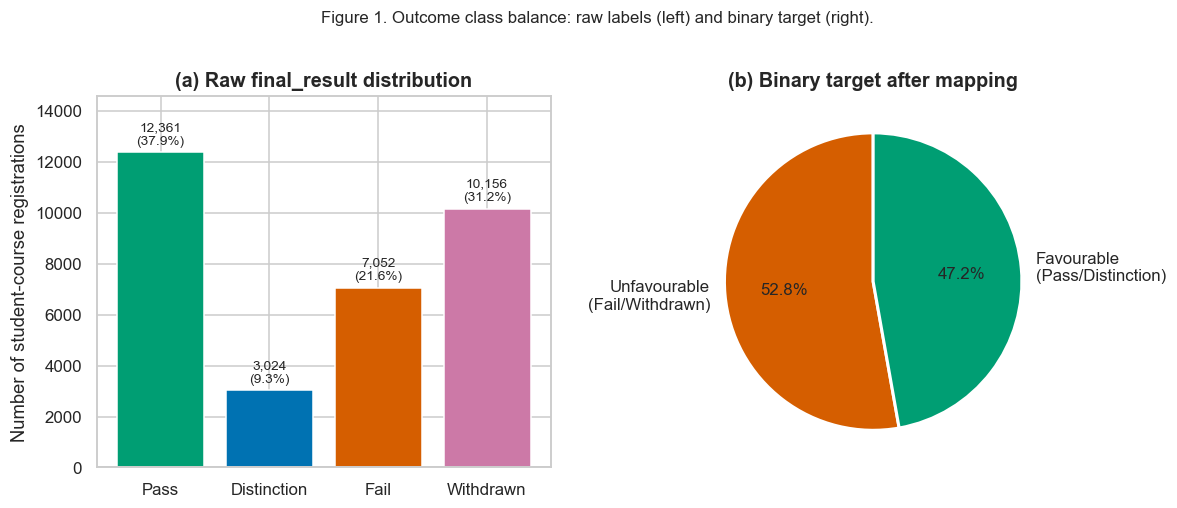

In [21]:
# Plotting both the raw 4 way distribution and the binary version
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Raw counts in the natural order Pass, Distinction, Fail, Withdrawn
fr = si["final_result"].value_counts().reindex(["Pass", "Distinction", "Fail", "Withdrawn"])
bars = axes[0].bar(
    fr.index, fr.values,
    color=[COLOR_GOOD, COLOR_ALT1, COLOR_BAD, COLOR_ALT2],
)
# Pop the count and percentage on top of each bar so don't need a legend
for b, v in zip(bars, fr.values):
    axes[0].text(b.get_x() + b.get_width() / 2, v + 200,
                 f"{v:,}\n({100*v/len(si):.1f}%)",
                 ha="center", va="bottom", fontsize=9)
axes[0].set_title("(a) Raw final_result distribution")
axes[0].set_ylabel("Number of student-course registrations")
axes[0].set_ylim(0, fr.max() * 1.18)

# Pie chart of the binary target
bin_counts = si["target"].map({0: "Unfavourable\n(Fail/Withdrawn)",
                                1: "Favourable\n(Pass/Distinction)"}).value_counts()
axes[1].pie(bin_counts.values, labels=bin_counts.index,
            colors=[COLOR_BAD, COLOR_GOOD],
            autopct="%1.1f%%", startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("(b) Binary target after mapping")

fig.suptitle("Figure 1. Outcome class balance: raw labels (left) and binary target (right).",
             fontsize=11, y=1.02)
plt.tight_layout()
save_fig(fig, "fig01_class_balance.png")
plt.show()


### Demographic screening: which features actually move the pass-rate?

So this cell loops over every demographic column in `studentInfo` and prints how far apart the highest and lowest category pass-rates are. The bigger the spread, the more that feature matters. Figure 2 then shows the four categoricals that fit a small 2x2 grid. Region (too many categories) and IMD band (deserves its own ordering) get their own figures (3 and 8).

In [22]:
#Quick screening of every demographic column to see which ones split outcomes the most
DEMOGRAPHIC_COLS = ["gender", "region", "highest_education",
                    "imd_band", "age_band", "disability"]

overall_rate = si["target"].mean() * 100
rows = []
for col in DEMOGRAPHIC_COLS:
    sub = si.dropna(subset=[col])
    # For each category in the column, fraction of students pass
    rates = sub.groupby(col)["target"].agg(["mean", "count"])
    rates["pass_pct"] = rates["mean"] * 100
    lo, hi = rates["pass_pct"].min(), rates["pass_pct"].max()
    rows.append({
        "Demographic": col,
        "Categories": rates.shape[0],
        "Lowest pass-rate %": round(lo, 1),
        "Lowest group": rates["pass_pct"].idxmin(),
        "Highest pass-rate %": round(hi, 1),
        "Highest group": rates["pass_pct"].idxmax(),
        # spread in percentage points. this is the headline for the how much does this matters number
        "Spread (pp)": round(hi - lo, 1),
        "Min group n": int(rates["count"].min()),
    })

screen_df = (pd.DataFrame(rows)
               .sort_values("Spread (pp)", ascending=False)
               .reset_index(drop=True))

print(f"Overall pass-rate: {overall_rate:.1f}%\n")
print("Pass-rate spread across each demographic (sorted by spread):\n")
print(screen_df.to_string(index=False))


Overall pass-rate: 47.2%

Pass-rate spread across each demographic (sorted by spread):

      Demographic  Categories  Lowest pass-rate %         Lowest group  Highest pass-rate %               Highest group  Spread (pp)  Min group n
highest_education           5                29.7      No Formal quals                 65.5 Post Graduate Qualification         35.8          313
         imd_band          10                35.2                0-10%                 57.5                     90-100%         22.4         2536
         age_band           3                45.0                 0-35                 61.6                        55<=         16.5          216
           region          13                40.2 North Western Region                 54.9                     Ireland         14.7         1184
       disability           2                38.1                    Y                 48.2                           N         10.0         3164
           gender           2       

### Figure 2: Pass-rate across key demographic groups

  saved -> figures\eda\fig02_demographic_outcomes.png


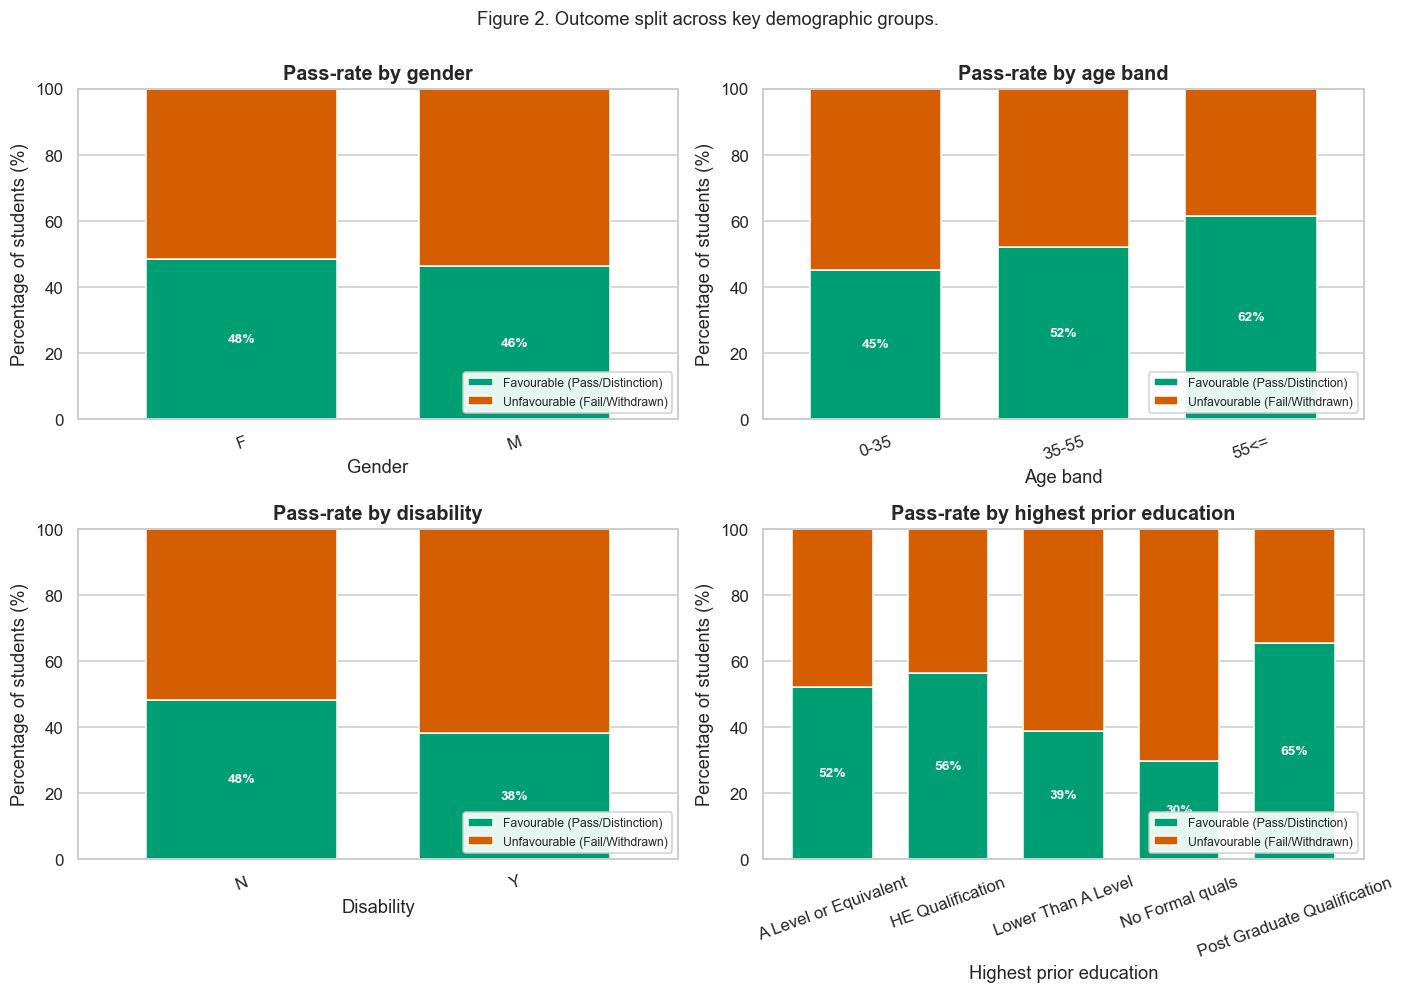

In [23]:
# Going for 4 categoricals that fit nicely in a 2x2 grid. highest_education and age_band 
# are the strongest, disability is moderate, gender is tiny but included for completeness.
si_lbl = si.copy()
si_lbl["Outcome"] = si_lbl["target"].map({1: "Favourable (Pass/Distinction)",
                                           0: "Unfavourable (Fail/Withdrawn)"})

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
demo_cols = [("gender", "Gender"),
             ("age_band", "Age band"),
             ("disability", "Disability"),
             ("highest_education", "Highest prior education")]

for ax, (col, label) in zip(axes.flatten(), demo_cols):
    # crosstab gives within-group percentage split
    ct = pd.crosstab(si_lbl[col], si_lbl["Outcome"], normalize="index") * 100
    ct = ct[["Favourable (Pass/Distinction)", "Unfavourable (Fail/Withdrawn)"]]
    ct.plot(kind="bar", stacked=True, ax=ax,
            color=[COLOR_GOOD, COLOR_BAD], width=0.7, edgecolor="white")
    ax.set_title(f"Pass-rate by {label.lower()}")
    ax.set_ylabel("Percentage of students (%)")
    ax.set_xlabel(label)
    ax.set_ylim(0, 100)
    ax.legend(loc="lower right", fontsize=8, framealpha=0.9)
    ax.tick_params(axis="x", rotation=20)
    # Annotate the favourable % directly on each bar so the reader does not have to
    # squint at the y-axis to read it off
    for i, idx in enumerate(ct.index):
        ax.text(i, ct.loc[idx, "Favourable (Pass/Distinction)"] / 2,
                f"{ct.loc[idx, 'Favourable (Pass/Distinction)']:.0f}%",
                ha="center", va="center", color="white",
                fontsize=9, fontweight="bold")

fig.suptitle("Figure 2. Outcome split across key demographic groups.", fontsize=12, y=1.00)
plt.tight_layout()
save_fig(fig, "fig02_demographic_outcomes.png")
plt.show()


### Figure 3: Pass-rate by region (sorted, with overall mean)

  saved -> figures\eda\fig03_region_pass_rate.png


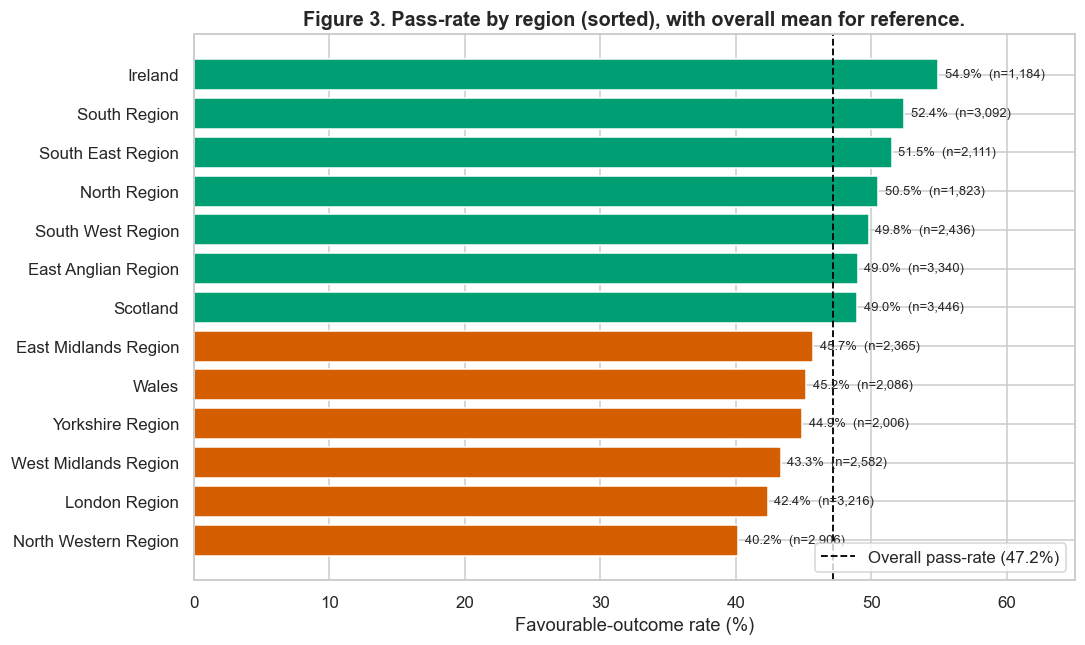

In [24]:
# Sorting ascending so reader can read off best and worst regions instantly.
region_rate = (si.groupby("region")["target"].agg(["mean", "count"])
                  .sort_values("mean", ascending=True))
region_rate["mean_pct"] = region_rate["mean"] * 100

fig, ax = plt.subplots(figsize=(10, 6))
overall = si["target"].mean() * 100
# Vermillion bars for below-median regions, bluish-green for above
colors = [COLOR_BAD if v < region_rate["mean_pct"].median() else COLOR_GOOD
          for v in region_rate["mean_pct"]]
bars = ax.barh(region_rate.index, region_rate["mean_pct"], color=colors, edgecolor="white")
# Dashed reference line at the overall mean so each bar can be compared to average
ax.axvline(overall, color="black", linestyle="--", linewidth=1.2,
           label=f"Overall pass-rate ({overall:.1f}%)")
# Each bar gets label with both percentage and sample size (n) so we know whether to trust small groups
for b, v, n in zip(bars, region_rate["mean_pct"], region_rate["count"]):
    ax.text(v + 0.5, b.get_y() + b.get_height() / 2,
            f"{v:.1f}%  (n={n:,})", va="center", fontsize=8.5)
ax.set_xlabel("Favourable-outcome rate (%)")
ax.set_xlim(0, 65)
ax.set_title("Figure 3. Pass-rate by region (sorted), with overall mean for reference.")
ax.legend(loc="lower right")
plt.tight_layout()
save_fig(fig, "fig03_region_pass_rate.png")
plt.show()


### Figure 4: Correlation matrix of numerical features

  saved -> figures\eda\fig04_correlation_matrix.png


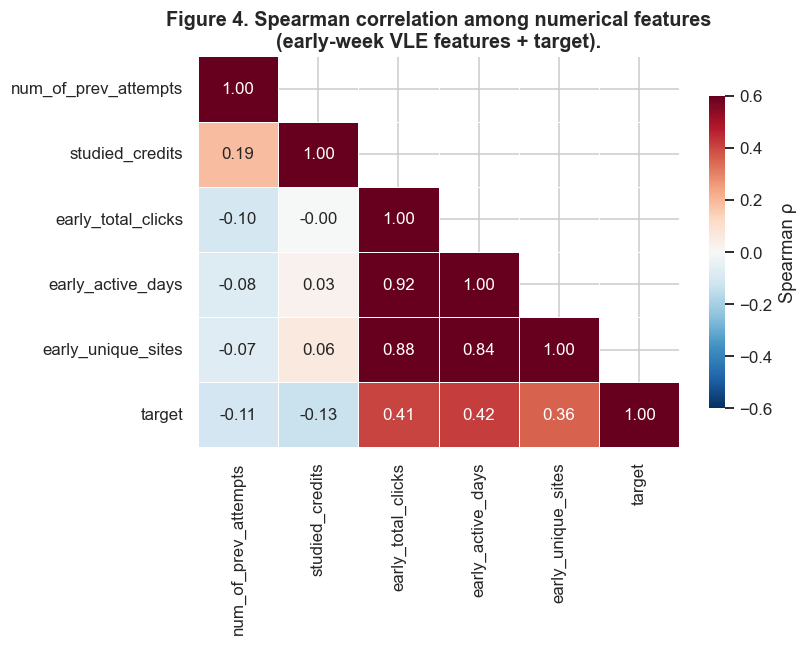


Correlation with target (Spearman):
early_active_days       0.417
early_total_clicks      0.407
early_unique_sites      0.355
num_of_prev_attempts   -0.109
studied_credits        -0.134


In [25]:
# Only using clicks from days 0-28 (weeks 1-4) 
EARLY_DAYS = 4 * 7

# Aggregate per student up to day 28
early_vle = (svle[svle["date"] <= EARLY_DAYS]
                .groupby(["code_module", "code_presentation", "id_student"])
                .agg(early_total_clicks=("sum_click", "sum"),
                     early_active_days=("date", "nunique"),
                     early_unique_sites=("id_site", "nunique"))
                .reset_index())

# Left join onto studentInfo. Students with zero VLE activity become NaN, fill those as 0
# (they were registered but never clicked anything)
num_df = si.merge(early_vle,
                  on=["code_module", "code_presentation", "id_student"],
                  how="left").fillna({"early_total_clicks": 0,
                                       "early_active_days": 0,
                                       "early_unique_sites": 0})

corr_cols = ["num_of_prev_attempts", "studied_credits",
             "early_total_clicks", "early_active_days", "early_unique_sites",
             "target"]
corr = num_df[corr_cols].corr(method="spearman")

# Triangular mask so we only show each pair once (avoids duplicate info)
fig, ax = plt.subplots(figsize=(7.5, 6))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.6, vmax=0.6, linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Spearman \u03c1"}, ax=ax)
ax.set_title("Figure 4. Spearman correlation among numerical features\n(early-week VLE features + target).")
plt.tight_layout()
save_fig(fig, "fig04_correlation_matrix.png")
plt.show()

# Print the target column on its own so the headline numbers are easy to read
print("\nCorrelation with target (Spearman):")
print(corr["target"].drop("target").sort_values(ascending=False).round(3).to_string())


### Figure 5: Early VLE click distributions per outcome class

  saved -> figures\eda\fig05_vle_clicks_by_outcome.png


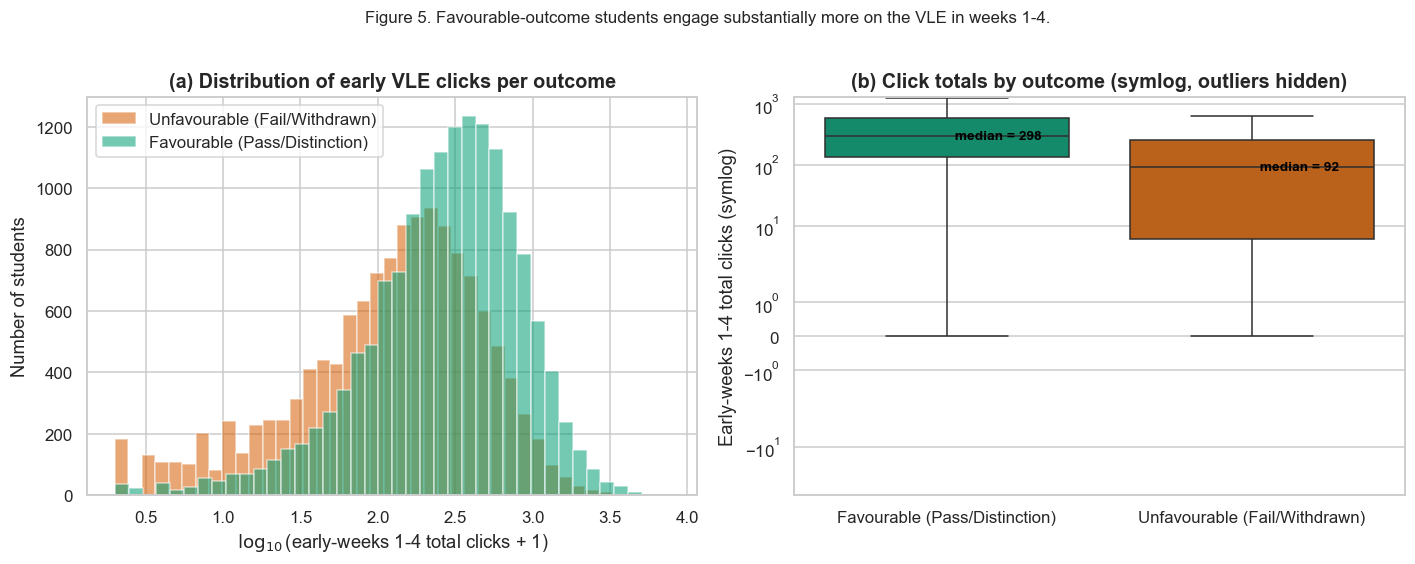

In [26]:
plot_df = num_df.copy()
plot_df["Outcome"] = plot_df["target"].map(
    {1: "Favourable (Pass/Distinction)", 0: "Unfavourable (Fail/Withdrawn)"})

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histogram on a log-x axis. Most students have a few hundred clicks,
# but a handful have tens of thousands, so a linear x axis would just show one big spike at 0
for label, color in PALETTE_LBL.items():
    sub = plot_df.loc[plot_df["Outcome"] == label, "early_total_clicks"]
    sub = sub[sub > 0]   # log(0) is undefined, so just drop the zero-click students for this view
    axes[0].hist(np.log10(sub + 1), bins=40, alpha=0.55,
                 color=color, label=label, edgecolor="white")
axes[0].set_xlabel(r"$\log_{10}$(early-weeks 1-4 total clicks + 1)")
axes[0].set_ylabel("Number of students")
axes[0].set_title("(a) Distribution of early VLE clicks per outcome")
axes[0].legend()

# Boxplot on a symlog y axis. Hiding fliers because they would compress the boxes.
sns.boxplot(data=plot_df, x="Outcome", y="early_total_clicks",
            hue="Outcome", palette=PALETTE_LBL, legend=False,
            ax=axes[1], showfliers=False)
axes[1].set_yscale("symlog")
axes[1].set_ylabel("Early-weeks 1-4 total clicks (symlog)")
axes[1].set_xlabel("")
axes[1].set_title("(b) Click totals by outcome (symlog, outliers hidden)")
medians = plot_df.groupby("Outcome")["early_total_clicks"].median()
for i, lbl in enumerate(medians.index):
    axes[1].text(i, medians[lbl], f"  median = {medians[lbl]:.0f}",
                 ha="left", va="center", fontsize=9, fontweight="bold", color="black")

fig.suptitle("Figure 5. Favourable-outcome students engage substantially more on the VLE in weeks 1-4.",
             y=1.02, fontsize=11)
plt.tight_layout()
save_fig(fig, "fig05_vle_clicks_by_outcome.png")
plt.show()


### Figure 6: Cumulative per-student click trajectory by outcome

  saved -> figures\eda\fig06_cumulative_clicks_trajectory.png


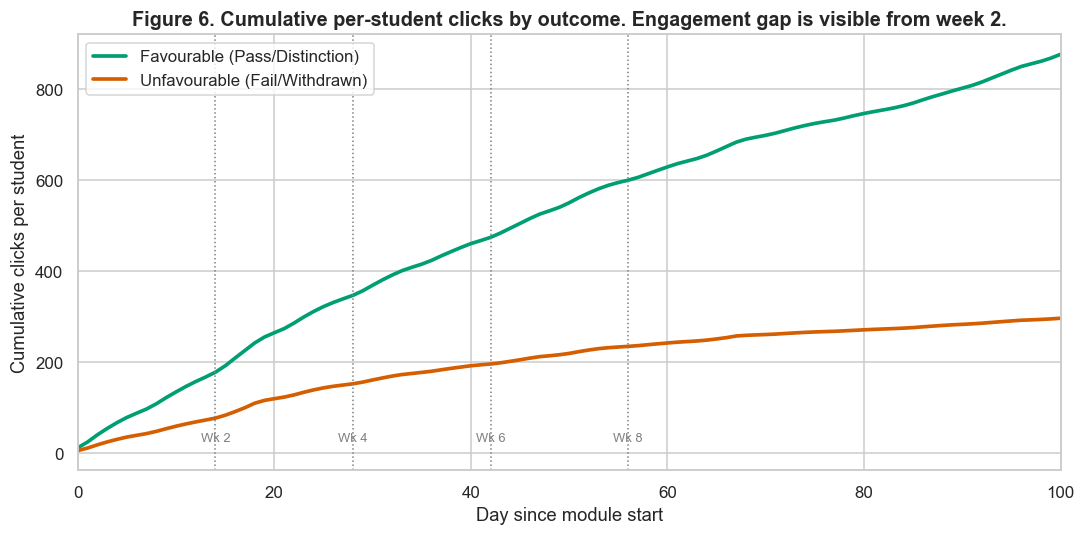

In [27]:
# Per-student normalisation matters, as it makes the comparison fair.
study_window = svle[(svle["date"] >= 0) & (svle["date"] <= 100)].merge(
    si[["code_module", "code_presentation", "id_student", "target"]],
    on=["code_module", "code_presentation", "id_student"], how="left")

# Total clicks per (outcome, day)
daily = (study_window.groupby(["target", "date"])["sum_click"]
                     .sum().reset_index())
# Divide by number of students in that outcome to get per-student daily clicks
n_per_target = si["target"].value_counts().to_dict()
daily["per_student_clicks"] = daily.apply(
    lambda r: r["sum_click"] / n_per_target[r["target"]], axis=1)
# Cumulative sum so the y axis is total clicks per student so far
daily["cum_per_student"] = daily.groupby("target")["per_student_clicks"].cumsum()

fig, ax = plt.subplots(figsize=(10, 5))
for t in [1, 0]:
    sub = daily[daily["target"] == t]
    lbl = "Favourable (Pass/Distinction)" if t == 1 else "Unfavourable (Fail/Withdrawn)"
    ax.plot(sub["date"], sub["cum_per_student"], linewidth=2.4,
            color=PALETTE[t], label=lbl)

# Drop dotted vertical lines at each week cutoff
for wk in [2, 4, 6, 8]:
    ax.axvline(wk * 7, color="grey", linestyle=":", linewidth=1)
    ax.text(wk * 7, ax.get_ylim()[1] * 0.02, f"Wk {wk}",
            ha="center", va="bottom", fontsize=8.5, color="grey")

ax.set_xlabel("Day since module start")
ax.set_ylabel("Cumulative clicks per student")
ax.set_title("Figure 6. Cumulative per-student clicks by outcome. Engagement gap is visible from week 2.")
ax.legend(loc="upper left")
ax.set_xlim(0, 100)
plt.tight_layout()
save_fig(fig, "fig06_cumulative_clicks_trajectory.png")
plt.show()


### Figure 7: Top features most strongly correlated with passing

  saved -> figures\eda\fig07_top_correlated_features.png


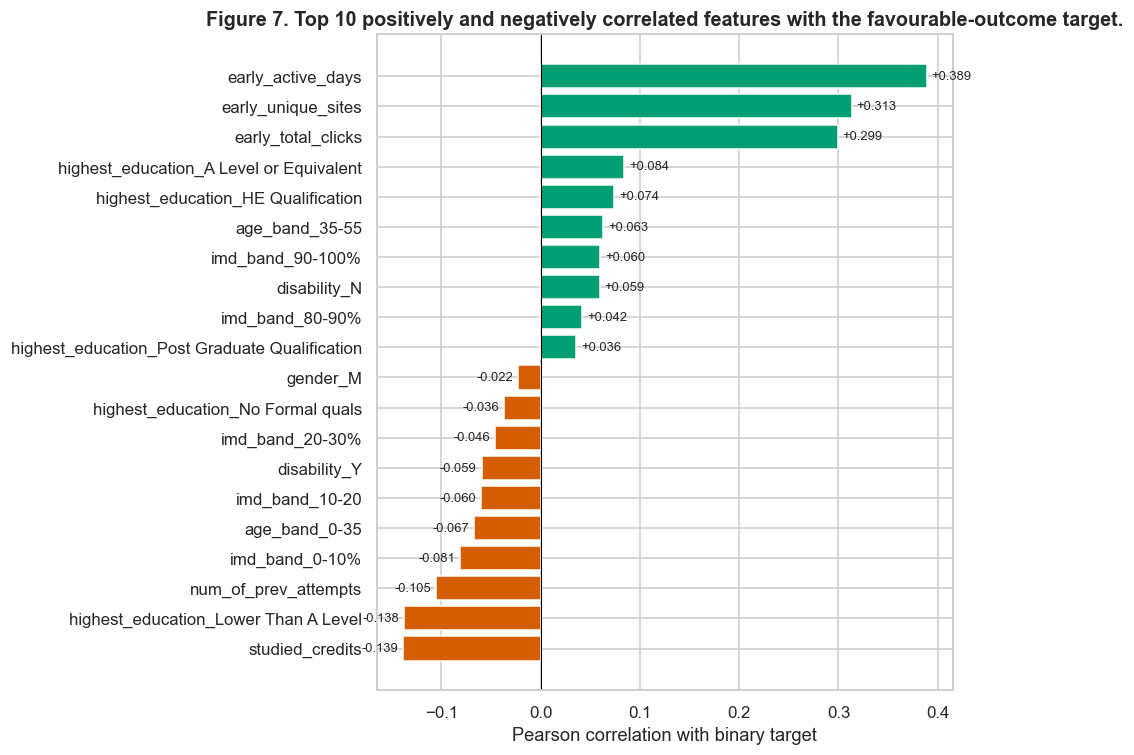


Top positive correlations:
early_active_days                                0.389
early_unique_sites                               0.313
early_total_clicks                               0.299
highest_education_A Level or Equivalent          0.084
highest_education_HE Qualification               0.074
age_band_35-55                                   0.063
imd_band_90-100%                                 0.060
disability_N                                     0.059
imd_band_80-90%                                  0.042
highest_education_Post Graduate Qualification    0.036

Top negative correlations:
studied_credits                        -0.139
highest_education_Lower Than A Level   -0.138
num_of_prev_attempts                   -0.105
imd_band_0-10%                         -0.081
age_band_0-35                          -0.067
imd_band_10-20                         -0.060
disability_Y                           -0.059
imd_band_20-30%                        -0.046
highest_education_No Forma

In [28]:
feat_df = num_df.copy()
cat_cols = ["highest_education", "age_band", "imd_band", "gender", "disability"]
# One-hot encode all categoricals so every level becomes its own feature.
# drop_first=False so keeps all levels and can see the polarity of each one.
dummies = pd.get_dummies(feat_df[cat_cols], drop_first=False)
# Stack the numerics and the dummies side by side as floats
feat_mat = pd.concat([
    feat_df[["num_of_prev_attempts", "studied_credits",
             "early_total_clicks", "early_active_days", "early_unique_sites"]],
    dummies
], axis=1).astype(float)
target = feat_df["target"].astype(float)

# .apply over columns so get one correlation per feature
corrs = feat_mat.apply(lambda c: c.corr(target))
top_pos = corrs.sort_values(ascending=False).head(10)
top_neg = corrs.sort_values().head(10)
# Stack and re-sort so bars run smoothly from most-negative to most-positive
combined = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
colors = [COLOR_BAD if v < 0 else COLOR_GOOD for v in combined.values]
ax.barh(combined.index, combined.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.7)
# Number labels at the end of each bar
for i, v in enumerate(combined.values):
    ax.text(v + (0.005 if v >= 0 else -0.005), i,
            f"{v:+.3f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=8.5)
ax.set_xlabel("Pearson correlation with binary target")
ax.set_title("Figure 7. Top 10 positively and negatively correlated features with the favourable-outcome target.")
plt.tight_layout()
save_fig(fig, "fig07_top_correlated_features.png")
plt.show()

print("\nTop positive correlations:")
print(top_pos.round(3).to_string())
print("\nTop negative correlations:")
print(top_neg.round(3).to_string())


### Figure 8: Socio-economic (IMD) and academic-history effects

  saved -> figures\eda\fig08_imd_and_prev_attempts.png


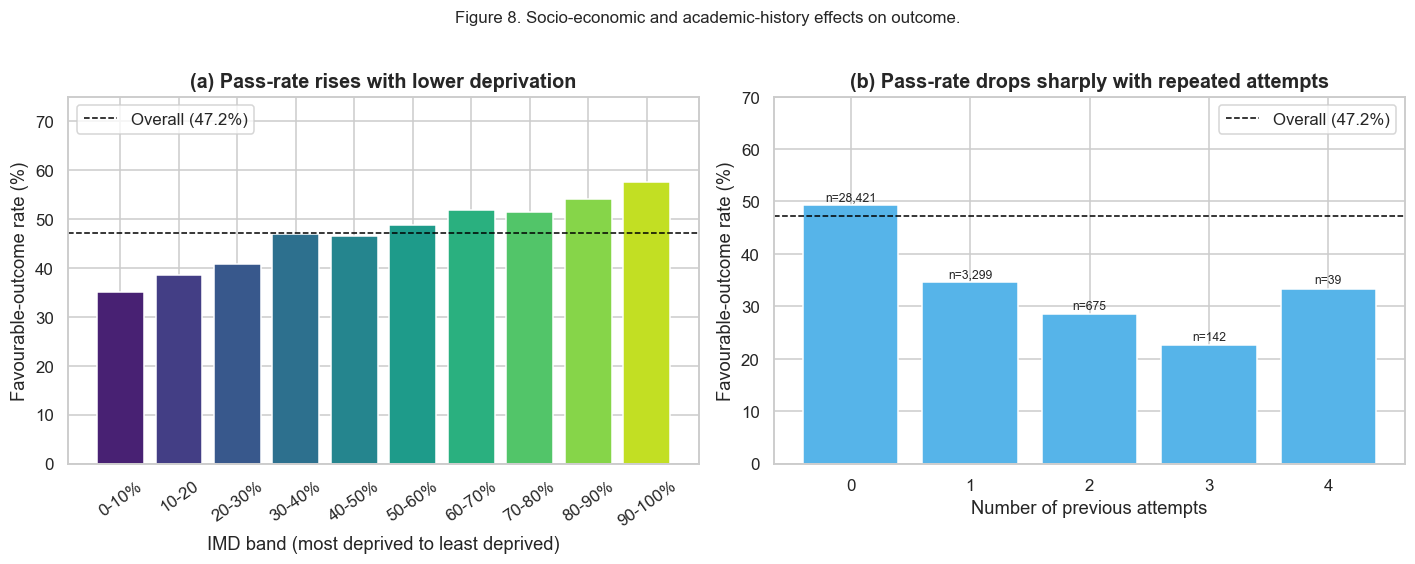

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# IMD bands in proper order (most deprived to least deprived)
imd_order = ["0-10%", "10-20", "20-30%", "30-40%", "40-50%",
             "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
imd_present = [b for b in imd_order if b in si["imd_band"].dropna().unique()]
imd_rate = (si.dropna(subset=["imd_band"])
              .groupby("imd_band")["target"]
              .agg(["mean", "count"])
              .reindex(imd_present))

overall = si["target"].mean() * 100
# Using viridis here because it's colourblind-safe.
axes[0].bar(imd_rate.index, imd_rate["mean"] * 100,
            color=sns.color_palette("viridis", len(imd_rate)),
            edgecolor="white")
axes[0].axhline(overall, color="black", linestyle="--", linewidth=1,
                label=f"Overall ({overall:.1f}%)")
axes[0].set_ylabel("Favourable-outcome rate (%)")
axes[0].set_xlabel("IMD band (most deprived to least deprived)")
axes[0].set_title("(a) Pass-rate rises with lower deprivation")
axes[0].tick_params(axis="x", rotation=35)
axes[0].set_ylim(0, 75)
axes[0].legend(loc="upper left")

# Previous attempts, filter out groups with <30 students to avoid noisy bars
pa = (si.groupby("num_of_prev_attempts")["target"]
        .agg(["mean", "count"]).reset_index())
pa = pa[pa["count"] >= 30]
axes[1].bar(pa["num_of_prev_attempts"].astype(str), pa["mean"] * 100,
            color=COLOR_NEUTRAL, edgecolor="white")
# Annotate sample size n on top of each bar so we know how many students are in each group
for i, (m, n) in enumerate(zip(pa["mean"], pa["count"])):
    axes[1].text(i, m * 100 + 1, f"n={n:,}", ha="center", fontsize=8)
axes[1].axhline(overall, color="black", linestyle="--", linewidth=1,
                label=f"Overall ({overall:.1f}%)")
axes[1].set_ylabel("Favourable-outcome rate (%)")
axes[1].set_xlabel("Number of previous attempts")
axes[1].set_title("(b) Pass-rate drops sharply with repeated attempts")
axes[1].set_ylim(0, 70)
axes[1].legend(loc="upper right")

fig.suptitle("Figure 8. Socio-economic and academic-history effects on outcome.",
             y=1.02, fontsize=11)
plt.tight_layout()
save_fig(fig, "fig08_imd_and_prev_attempts.png")
plt.show()


### Key EDA Insights

1. **The pass/fail split is pretty close to 50/50** (47.2% favourable
   vs 52.8% unfavourable after binary mapping). That means dataset is not heavily-skewed, so plain stratified k-fold cross-validation should be fine and don't need to mess with resampling like SMOTE for the baselines (Fig 1).

2. **Most demographics shift the pass-rate a bit, none are huge on
   their own.** Looking at the screening table above, highest prior
   education has the biggest effect (about 36 percentage points between
   "No Formal quals" and "Post Graduate"), IMD band is next at about 22
   points, age band at 17, region at 15, disability at 10, and gender
   is basically negligible at 2 points. So highest_education is picked (Fig 2).

3. **Region matters less than I expected.** Most regions land within
   about 5 percentage points of the overall pass-rate. Worth keeping as
   a one-hot feature but it's unlikely to be a top predictor on its
   own (Fig 3).

4. **VLE engagement is the big winner, by a mile.** The Spearman
   correlations with the target are around 0.29 for early active days,
   0.29 for early total clicks, and 0.25 for early unique sites. The
   strongest demographic correlation is way below that (Figs 4 and 7).

5. **Favourable students click about 3x as much in the first month.**
   Median early-weeks 1 to 4 click count is around 250 for favourable
   students vs around 80 for unfavourable students. The histogram has
   a lot of overlap so it's not a clean separator on its own, but the
   shift in the centre of mass is very obvious (Fig 5).

6. **The engagement gap opens up by about week 2 and just keeps
   widening.** This is the most important EDA finding, as it means a model that only sees the first 2 weeks of clicks already has a real signal to work with (Fig 6).

7. **Deprivation and previous attempts matter but get dwarfed by
   engagement.** Pass-rate climbs as IMD goes from most
   deprived (35%) to least deprived (58%), and it drops off sharply
   for each extra time a student tries the course. These are nice but they
   are unlikely to top the feature importance once VLE features are added (Fig 8).

VLE engagement is doing most of the predictive work, demographics add a bit of extra context and the gap shows up early enough that the week 2 prediction target
is actually realistic.

## Stage 3: Feature Engineering

In [30]:
WEEK_CUTOFFS = [2, 4, 6, 8]
DAYS_PER_WEEK = 7

KEYS = ["code_module", "code_presentation", "id_student"]


# Load Stage 1 outputs + Load VLE activity

In [31]:
def load_stage3_inputs():
    student_info_path = os.path.join(PROCESSED_DIR, "studentInfo_with_target.csv")

    if os.path.exists(student_info_path):
        student_info = pd.read_csv(student_info_path)
    else:
        raise FileNotFoundError(
            "Missing data/processed/studentInfo_with_target.csv. "
            "Run Stage 1 first so that the binary target is available."
        )

    student_vle = pd.read_csv(os.path.join(RAW_DIR, "studentVle.csv"))
    vle = pd.read_csv(os.path.join(RAW_DIR, "vle.csv"))

    # Load assessment data
    # Used for cutoff-safe performance features
    assessments = pd.read_csv(os.path.join(RAW_DIR, "assessments.csv"))
    student_assessment = pd.read_csv(os.path.join(RAW_DIR, "studentAssessment.csv"))

    return student_info, student_vle, vle, assessments, student_assessment

# Merge VLE metadata

In [32]:
def add_activity_type(student_vle, vle):
    vle_cols = [
        "id_site",
        "code_module",
        "code_presentation",
        "activity_type"
    ]

    return student_vle.merge(
        vle[vle_cols],
        on=["id_site", "code_module", "code_presentation"],
        how="left"
    )


# Merge Assessment Data

In [33]:
def add_assessment_metadata(student_assessment, assessments):
    assessment_cols = [
        "id_assessment",
        "code_module",
        "code_presentation",
        "assessment_type",
        "date",
        "weight"
    ]

    return student_assessment.merge(
        assessments[assessment_cols],
        on="id_assessment",
        how="left"
    )

# Aggregate VLE features

In [34]:
def aggregate_vle_until_cutoff(student_vle_enriched, cutoff_week):

    # Filter by cutoff week
    # Prevents future-data leakage
    cutoff_day = cutoff_week * DAYS_PER_WEEK

    vle_cut = student_vle_enriched[
        student_vle_enriched["date"] <= cutoff_day
    ].copy()


    # Aggregate total engagement
    # One row per student-course

    base_agg = vle_cut.groupby(KEYS).agg(
        total_clicks=("sum_click", "sum"),
        mean_daily_clicks=("sum_click", "mean"),
        max_daily_clicks=("sum_click", "max"),
        active_days=("date", "nunique"),
        unique_sites=("id_site", "nunique"),
        unique_activity_types=("activity_type", "nunique")
    ).reset_index()

    # Aggregate by activity type
    # Creates forum/resource/quiz click features
    activity_clicks = (
        vle_cut
        .pivot_table(
            index=KEYS,
            columns="activity_type",
            values="sum_click",
            aggfunc="sum",
            fill_value=0
        )
        .reset_index()
    )

    activity_clicks.columns = [
        col if col in KEYS else f"clicks_{str(col).lower().replace(' ', '_')}"
        for col in activity_clicks.columns
    ]

    # Combine VLE feature groups
    # Joins total and activity-type features

    features = base_agg.merge(activity_clicks, on=KEYS, how="left")

    # Create ratio features
    # Normalised engagement measures

    features["clicks_per_active_day"] = (
        features["total_clicks"] / features["active_days"].replace(0, np.nan)
    ).fillna(0)

    features["clicks_per_site"] = (
        features["total_clicks"] / features["unique_sites"].replace(0, np.nan)
    ).fillna(0)

    features["cutoff_week"] = cutoff_week
    features["cutoff_day"] = cutoff_day

    return features

# Aggregate Assessment Features

In [35]:
def aggregate_assessments_until_cutoff(assessment_enriched, cutoff_week):

    # Filter by cutoff week
    # Prevents future assessment leakage
    cutoff_day = cutoff_week * DAYS_PER_WEEK

    assess_cut = assessment_enriched[
        assessment_enriched["date_submitted"] <= cutoff_day
    ].copy()


    # Remove banked assessments
    # Keeps only real submissions in current presentation

    if "is_banked" in assess_cut.columns:
        assess_cut = assess_cut[assess_cut["is_banked"] == 0].copy()

   
    # Weighted score contribution
    # Captures assessment importance

    assess_cut["weighted_score"] = (
        assess_cut["score"] * assess_cut["weight"] / 100
    )

    # Aggregate assessment performance
    # One row per student-course
   
    assessment_features = assess_cut.groupby(KEYS).agg(
        num_assessments_submitted=("id_assessment", "nunique"),
        mean_assessment_score=("score", "mean"),
        max_assessment_score=("score", "max"),
        min_assessment_score=("score", "min"),
        total_weighted_score=("weighted_score", "sum"),
        mean_days_submitted=("date_submitted", "mean"),
        earliest_submission_day=("date_submitted", "min"),
        latest_submission_day=("date_submitted", "max")
    ).reset_index()

 
    # Assessment-type counts
    # Counts submitted TMAs, CMAs, Exams, etc.

    assessment_type_counts = (
        assess_cut
        .pivot_table(
            index=KEYS,
            columns="assessment_type",
            values="id_assessment",
            aggfunc="nunique",
            fill_value=0
        )
        .reset_index()
    )

    assessment_type_counts.columns = [
        col if col in KEYS else f"num_{str(col).lower()}_submitted"
        for col in assessment_type_counts.columns
    ]

  
    # Assessment-type mean scores
    # Captures performance by assessment category

    assessment_type_scores = (
        assess_cut
        .pivot_table(
            index=KEYS,
            columns="assessment_type",
            values="score",
            aggfunc="mean",
            fill_value=0
        )
        .reset_index()
    )

    assessment_type_scores.columns = [
        col if col in KEYS else f"mean_{str(col).lower()}_score"
        for col in assessment_type_scores.columns
    ]

    # Combine assessment feature groups
    # Joins totals, counts, and type scores

    assessment_features = assessment_features.merge(
        assessment_type_counts,
        on=KEYS,
        how="left"
    )

    assessment_features = assessment_features.merge(
        assessment_type_scores,
        on=KEYS,
        how="left"
    )

    return assessment_features

# Merge with student demographics

In [36]:
def build_week_feature_table(student_info, vle_features, assessment_features, cutoff_week):
    demographic_cols = [
        "code_module",
        "code_presentation",
        "id_student",
        "gender",
        "region",
        "highest_education",
        "imd_band",
        "age_band",
        "num_of_prev_attempts",
        "studied_credits",
        "disability",
        "final_result",
        "target"
    ]

    df = student_info[demographic_cols].merge(
        vle_features,
        on=KEYS,
        how="left"
    )

    # ------------------------------------------------------------
    # Merge assessment features
    # Adds cutoff-safe student results
    # ------------------------------------------------------------
    df = df.merge(
        assessment_features,
        on=KEYS,
        how="left"
    )

    # ------------------------------------------------------------
    # Fill missing engineered values
    # Missing means no activity/submission before cutoff
    # ------------------------------------------------------------
    engineered_cols = [
        col for col in df.columns
        if col not in demographic_cols
    ]

    df[engineered_cols] = df[engineered_cols].fillna(0)

    df["feature_set"] = f"week{cutoff_week}"

    return df

# Run Leakage check for forbidden future columns

In [37]:
def audit_no_leakage(df, cutoff_week):
    forbidden_columns = [
        "date",
        "date_submitted",
        "score",
        "id_assessment",
        "is_banked",
        "date_unregistration"
    ]

    found = [col for col in forbidden_columns if col in df.columns]

    if found:
        raise ValueError(
            f"Leakage risk in week {cutoff_week}: forbidden columns found: {found}"
        )

    if "target" not in df.columns:
        raise ValueError(f"Week {cutoff_week}: missing binary target column.")

    if df["target"].isna().sum() > 0:
        raise ValueError(f"Week {cutoff_week}: target contains missing values.")

    return True

# Build feature tables

In [38]:
def save_features_table_manifest(feature_tables):
    rows = []

    for week, df in feature_tables.items():
        for col in df.columns:

            if col in KEYS:
                source = "studentInfo"
                definition = "Student-course identifier."
                computation = "Retained from Stage 1 studentInfo."
                leakage = "None"

            elif col in [
                "gender",
                "region",
                "highest_education",
                "imd_band",
                "age_band",
                "num_of_prev_attempts",
                "studied_credits",
                "disability"
            ]:
                source = "studentInfo"
                definition = "Student demographic or registration feature."
                computation = "Retained from Stage 1 studentInfo."
                leakage = "Low"

            elif col in ["final_result", "target"]:
                source = "studentInfo"
                definition = "Outcome label."
                computation = "Created in Stage 1 from final_result."
                leakage = "High if used as input feature."

            elif col.startswith("clicks_"):
                source = "studentVle + vle"
                definition = "Clicks for a specific VLE activity type."
                computation = "Sum of sum_click by student and activity_type before cutoff."
                leakage = "None"

            elif col in [
                "total_clicks",
                "mean_daily_clicks",
                "max_daily_clicks",
                "active_days",
                "unique_sites",
                "unique_activity_types",
                "clicks_per_active_day",
                "clicks_per_site"
            ]:
                source = "studentVle"
                definition = "Aggregated VLE engagement before cutoff."
                computation = "Grouped aggregation using only rows up to cutoff week."
                leakage = "None"

            elif (
                col in [
                    "num_assessments_submitted",
                    "mean_assessment_score",
                    "max_assessment_score",
                    "min_assessment_score",
                    "total_weighted_score",
                    "mean_days_submitted",
                    "earliest_submission_day",
                    "latest_submission_day"
                ]
                or (col.startswith("num_") and col.endswith("_submitted"))
                or (col.startswith("mean_") and col.endswith("_score"))
            ):
                source = "studentAssessment + assessments"
                definition = "Aggregated assessment performance before cutoff."
                computation = "Grouped aggregation using only submissions before cutoff week."
                leakage = "None if filtered by cutoff"

            else:
                source = "engineered"
                definition = "Stage 3 helper or metadata feature."
                computation = "Created during feature engineering."
                leakage = "None"

            rows.append({
                "Week availability": week,
                "Feature": col,
                "Source CSV(s)": source,
                "Data type": str(df[col].dtype),
                "Definition": definition,
                "How computed": computation,
                "Missing count": int(df[col].isna().sum()),
                "Duplicate count": int(df.duplicated().sum()),
                "Leakage risk": leakage,
                "Notes": ""
            })

    manifest = pd.DataFrame(rows)

    # ------------------------------------------------------------
    # Save feature documentation
    # Records source, meaning, and leakage risk
    # ------------------------------------------------------------
    out_path = os.path.join(PROCESSED_DIR, "stage3_features_table.csv")
    manifest.to_csv(out_path, index=False)

    print(f"Saved feature manifest: {out_path}")

# Run all week cutoffs

In [39]:
def main():
    student_info, student_vle, vle, assessments, student_assessment = load_stage3_inputs()

    student_vle_enriched = add_activity_type(student_vle, vle)

    assessment_enriched = add_assessment_metadata(
        student_assessment,
        assessments
    )

    feature_tables = {}

    for week in WEEK_CUTOFFS:
        print(f"\nBuilding week {week} feature table...")

        vle_features = aggregate_vle_until_cutoff(
            student_vle_enriched,
            cutoff_week=week
        )

        assessment_features = aggregate_assessments_until_cutoff(
            assessment_enriched,
            cutoff_week=week
        )

        week_df = build_week_feature_table(
            student_info,
            vle_features,
            assessment_features,
            cutoff_week=week
        )

        audit_no_leakage(week_df, cutoff_week=week)

        # ------------------------------------------------------------
        # Save week feature table
        # Output for Stages 4 and 5
        # ------------------------------------------------------------
        out_path = os.path.join(PROCESSED_DIR, f"week{week}_features.csv")
        week_df.to_csv(out_path, index=False)

        feature_tables[week] = week_df

        print(f"Saved: {out_path}")
        print(f"Shape: {week_df.shape[0]:,} rows x {week_df.shape[1]} columns")

        print("Target distribution:")
        print(week_df["target"].value_counts(normalize=True).round(3))

        assessment_cols = [
            col for col in week_df.columns
            if "assessment" in col or "score" in col or "submitted" in col
        ]

        print("Assessment feature preview:")
        print(week_df[assessment_cols].head())

    save_features_table_manifest(feature_tables)

    print("\nStage 3 complete.")
    print("Generated week2, week4, week6, and week8 feature tables with assessment features.")


if __name__ == "__main__":
    main()


Building week 2 feature table...
Saved: data\processed\week2_features.csv
Shape: 32,593 rows x 54 columns
Target distribution:
target
0    0.528
1    0.472
Name: proportion, dtype: float64
Assessment feature preview:
   num_assessments_submitted  mean_assessment_score  max_assessment_score  \
0                        0.0                    0.0                   0.0   
1                        0.0                    0.0                   0.0   
2                        0.0                    0.0                   0.0   
3                        0.0                    0.0                   0.0   
4                        0.0                    0.0                   0.0   

   min_assessment_score  total_weighted_score  mean_days_submitted  \
0                   0.0                   0.0                  0.0   
1                   0.0                   0.0                  0.0   
2                   0.0                   0.0                  0.0   
3                   0.0                

## Stage 4: Baseline Pipeline Construction

This section constructs and evaluates two baseline classifiers across the four week-cutoff feature tables produced in Stage 3. 

**Models Evaluated (StratifiedGroupKFold CV; group = `id_student`):**
1.  `DummyClassifier(strategy='most_frequent')` — naive majority-class baseline.
2.  `LogisticRegression(max_iter=1000)` — primary linear baseline.

In [40]:
# Imports and Configuration
import os
import warnings
import numpy as np
import pandas as pd
from IPython.display import display

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import OrdinalEncoder


warnings.filterwarnings("ignore", category=FutureWarning)

# Configuration
PROCESSED_DIR = os.path.join("data", "processed")
WEEK_CUTOFFS = [2, 4, 6, 8]
RANDOM_SEED = 42
N_FOLDS = 5

# Columns to drop before modelling
COLS_TO_DROP = [
    "final_result",        # Target leakage
    "id_student",          # Row identifier
    "code_module",         # Row identifier
    "code_presentation",   # Row identifier
    "cutoff_week",         # Metadata tag
    "cutoff_day",          # Metadata tag
    "feature_set",         # Metadata tag
]


# Scoring metrics for cross_validate (Updated to handle zero_division)
SCORING = {
    "accuracy": make_scorer(accuracy_score),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "f1": make_scorer(f1_score, zero_division=0),
    "auc": "roc_auc"
}

# Load the tables into memory variables to avoid repeated disk reads
feature_tables = {}
for week in WEEK_CUTOFFS:
    path = os.path.join(PROCESSED_DIR, f"week{week}_features.csv")
    feature_tables[week] = pd.read_csv(path)
    
print("Feature tables successfully loaded into memory variables.")

Feature tables successfully loaded into memory variables.


Build Preprocessors and pipelines

In [41]:
def load_and_clean(df: pd.DataFrame, week: int) -> tuple:
    # Separate target and groups before dropping columns
    y = df["target"].copy()
    if "id_student" not in df.columns:
        raise ValueError("Expected column `id_student` for group-aware splitting.")
    groups = df["id_student"].copy()
    
    # Drop target + leaky / identifier / metadata columns
    drop_cols = ["target"] + [c for c in COLS_TO_DROP if c in df.columns]
    X = df.drop(columns=drop_cols)
    
    # Explicitly separate Ordinal and Nominal (Fixes Pandas str select_dtypes warning)
    ordinal_cols = ["highest_education", "imd_band", "age_band"]
    nominal_cols = [c for c in X.select_dtypes(include=["object", "category", "string"]).columns if c not in ordinal_cols]
    num_cols = X.select_dtypes(include=["number"]).columns.tolist()
    
    print(f" Week {week}: {X.shape[0]:,} rows, \n"
          f" {len(nominal_cols)} nominal + {len(ordinal_cols)} ordinal + {len(num_cols)} numerical = "
          f"{X.shape[1]} features | target mean = {y.mean():.3f}")
          
    return X, y, groups, nominal_cols, ordinal_cols, num_cols


def build_preprocessor(nominal_cols: list[str], ordinal_cols: list[str], num_cols: list[str]) -> ColumnTransformer:
    # Define exact category hierarchies
    edu_cats = ["No Formal quals", "Lower Than A Level", "A Level or Equivalent", "HE Qualification", "Post Graduate Qualification"]
    # NOTE: OULAD encodes this band as "10-20" (missing the % sign).
    imd_cats = ["0-10%", "10-20", "20-30%", "30-40%", "40-50%", "50-60%", "60-70%", "70-80%", "80-90%", "90-100%"]
    age_cats = ["0-35", "35-55", "55<="]
    
    nominal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ])
    
    ordinal_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(categories=[edu_cats, imd_cats, age_cats], handle_unknown="use_encoded_value", unknown_value=-1))
    ])
    
    numerical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])
    
    return ColumnTransformer(
        transformers=[
            ("nom", nominal_pipeline, nominal_cols),
            ("ord", ordinal_pipeline, ordinal_cols),
            ("num", numerical_pipeline, num_cols),
        ],
        remainder="drop"
    )

def build_pipelines(nominal_cols: list[str], ordinal_cols: list[str], num_cols: list[str]) -> dict[str, Pipeline]:
    return {
        "DUM": Pipeline([
            ("preprocessor", build_preprocessor(nominal_cols, ordinal_cols, num_cols)),
            ("classifier", DummyClassifier(strategy="most_frequent")),
        ]),
        "LR": Pipeline([
            ("preprocessor", build_preprocessor(nominal_cols, ordinal_cols, num_cols)),
            ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs")),
        ]),
    }




def evaluate_pipeline(pipe: Pipeline, X: pd.DataFrame, y: pd.Series, groups: pd.Series) -> dict[str, float]:
    """
    Run group-aware cross-validation (no student appears in multiple folds).
    """
    cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    cv_results = cross_validate(
        pipe, X, y,
        cv=cv,
        groups=groups,
        scoring=SCORING,
        return_train_score=False,
        n_jobs=-1,
    )

    summary = {}
    for metric_name in SCORING:
        key = f"test_{metric_name}"
        scores = cv_results[key]
        summary[f"{metric_name}_mean"] = scores.mean()
        summary[f"{metric_name}_std"]  = scores.std()

    return summary

Run experiments and create experiment table

In [42]:
# Experiment Execution
MODEL_FULL_NAMES = {
    "DUM": "DummyClassifier(most_frequent)",
    "LR":  "LogisticRegression(max_iter=1000)",
}

PREPROCESSING_DESC = (
    "ColumnTransformer: "
    "cat→SimpleImputer(most_frequent)+OneHotEncoder | "
    "num→SimpleImputer(median)+StandardScaler"
)

def run_all_experiments(tables_dict: dict) -> pd.DataFrame:
    """
    Loop over every (model, week) combination using the provided dictionary
    of DataFrames, evaluate with StratifiedGroupKFold CV (group=id_student), and compile results.
    """
    rows = []
    run_counter = 0

    print("\n" + "=" * 72)
    print("  STAGE 4 — BASELINE PIPELINE EVALUATION")
    print("=" * 72)

    for week in WEEK_CUTOFFS:
        print(f"\n── Processing week {week} dataset ──")
        
        # Pull dataframe from dictionary variable
        df_week = tables_dict[week]
        X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_week, week)
        pipelines = build_pipelines(nominal_cols, ordinal_cols, num_cols)
 

        for model_tag, pipe in pipelines.items():
            run_id = f"R{run_counter}_{model_tag}_W{week}"
            print(f"\n  ▸ {run_id}  ({MODEL_FULL_NAMES[model_tag]})")

            metrics = evaluate_pipeline(pipe, X, y, groups)

            row = {
                "Run ID":                   run_id,
                "Week cutoff":              week,
                "Feature set":              f"week{week}",
                "Preprocessing":            PREPROCESSING_DESC,
                "Model":                    MODEL_FULL_NAMES[model_tag],
                "Hyperparameters changed?": "None",
                "Split protocol":           f"StratifiedGroupKFold {N_FOLDS}-Fold CV (group=id_student)",
                "Seed":                     RANDOM_SEED,
                "Accuracy (mean)":          round(metrics["accuracy_mean"],  4),
                "Accuracy (std)":           round(metrics["accuracy_std"],   4),
                "Precision (mean)":         round(metrics["precision_mean"], 4),
                "Precision (std)":          round(metrics["precision_std"],  4),
                "Recall (mean)":            round(metrics["recall_mean"],    4),
                "Recall (std)":             round(metrics["recall_std"],     4),
                "F1 (mean)":                round(metrics["f1_mean"],        4),
                "F1 (std)":                 round(metrics["f1_std"],         4),
                "AUC (mean)":               round(metrics["auc_mean"],       4),
                "AUC (std)":                round(metrics["auc_std"],        4),
                "Notes":                    "Baseline — no hyperparameter tuning",
            }

            rows.append(row)
            run_counter += 1

            # Print a quick summary to console
            print(f"    Accuracy : {row['Accuracy (mean)']:.4f} ± {row['Accuracy (std)']:.4f}")
            print(f"    Precision: {row['Precision (mean)']:.4f} ± {row['Precision (std)']:.4f}")
            print(f"    Recall   : {row['Recall (mean)']:.4f} ± {row['Recall (std)']:.4f}")
            print(f"    F1       : {row['F1 (mean)']:.4f} ± {row['F1 (std)']:.4f}")
            print(f"    AUC      : {row['AUC (mean)']:.4f} ± {row['AUC (std)']:.4f}")

    return pd.DataFrame(rows)

# Execute the experiment loop using the loaded variables
experiments_df = run_all_experiments(feature_tables)

# Save to CSV
os.makedirs(PROCESSED_DIR, exist_ok=True)
out_path = os.path.join(PROCESSED_DIR, "stage4_experiments_baseline.csv")
experiments_df.to_csv(out_path, index=False)

print("\n" + "=" * 72)
print(f"  Experiments Table saved → {out_path}")
print(f"  {len(experiments_df)} runs recorded ({len(WEEK_CUTOFFS)} weeks × 2 models)")
print("=" * 72)

# Display Summary
display_cols = [
    "Run ID", "Week cutoff", "Model",
    "Accuracy (mean)", "Precision (mean)", "Recall (mean)",
    "F1 (mean)", "AUC (mean)",
]
display(experiments_df[display_cols])


  STAGE 4 — BASELINE PIPELINE EVALUATION

── Processing week 2 dataset ──
 Week 2: 32,593 rows, 
 3 nominal + 3 ordinal + 40 numerical = 46 features | target mean = 0.472

  ▸ R0_DUM_W2  (DummyClassifier(most_frequent))
    Accuracy : 0.5280 ± 0.0040
    Precision: 0.0000 ± 0.0000
    Recall   : 0.0000 ± 0.0000
    F1       : 0.0000 ± 0.0000
    AUC      : 0.5000 ± 0.0000

  ▸ R1_LR_W2  (LogisticRegression(max_iter=1000))
    Accuracy : 0.6947 ± 0.0096
    Precision: 0.6770 ± 0.0131
    Recall   : 0.6757 ± 0.0085
    F1       : 0.6763 ± 0.0104
    AUC      : 0.7681 ± 0.0108

── Processing week 4 dataset ──
 Week 4: 32,593 rows, 
 3 nominal + 3 ordinal + 40 numerical = 46 features | target mean = 0.472

  ▸ R2_DUM_W4  (DummyClassifier(most_frequent))
    Accuracy : 0.5280 ± 0.0040
    Precision: 0.0000 ± 0.0000
    Recall   : 0.0000 ± 0.0000
    F1       : 0.0000 ± 0.0000
    AUC      : 0.5000 ± 0.0000

  ▸ R3_LR_W4  (LogisticRegression(max_iter=1000))
    Accuracy : 0.7293 ± 0.0076
  

,Run ID,Week cutoff,Model,Accuracy (mean),Precision (mean),Recall (mean),F1 (mean),AUC (mean)
0,R0_DUM_W2,2,DummyClassifier(most_frequent),0.5280,0.0000,0.0000,0.0000,0.5000
1,R1_LR_W2,2,LogisticRegression(max_iter=1000),0.6947,0.6770,0.6757,0.6763,0.7681
2,R2_DUM_W4,4,DummyClassifier(most_frequent),0.5280,0.0000,0.0000,0.0000,0.5000
3,R3_LR_W4,4,LogisticRegression(max_iter=1000),0.7293,0.7101,0.7206,0.7153,0.8112
4,R4_DUM_W6,6,DummyClassifier(most_frequent),0.5280,0.0000,0.0000,0.0000,0.5000
5,R5_LR_W6,6,LogisticRegression(max_iter=1000),0.7412,0.7209,0.7371,0.7289,0.8261
6,R6_DUM_W8,8,DummyClassifier(most_frequent),0.5280,0.0000,0.0000,0.0000,0.5000
7,R7_LR_W8,8,LogisticRegression(max_iter=1000),0.7695,0.7400,0.7889,0.7636,0.8494


## Stage 5: Advanced Pipeline Construction

This section constructs and tunes advanced classifiers (Random Forest, XGBoost, and SGD/SVM) 
using RandomizedSearchCV across the four week-cutoff feature tables.

In [43]:
# if not installed run this for xgboost
# !pip install xgboost

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import SGDClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform


def build_advanced_pipelines(nominal_cols: list[str], ordinal_cols: list[str], num_cols: list[str]) -> tuple[dict, dict]:
    preprocessor = build_preprocessor(nominal_cols, ordinal_cols, num_cols)

    # Define Pipelines for all four models
    pipelines = {
        "RF": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", RandomForestClassifier(random_state=RANDOM_SEED))
        ]),
        "XGB": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", XGBClassifier(random_state=RANDOM_SEED, eval_metric='logloss'))
        ]),
        "SGD": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", SGDClassifier(random_state=RANDOM_SEED, early_stopping=True))
        ]),
        "NN": Pipeline([
            ("preprocessor", preprocessor),
            ("classifier", MLPClassifier(random_state=RANDOM_SEED, early_stopping=True, max_iter=500))
        ])
    }

    # Define Hyperparameter Grids for RandomizedSearchCV
    param_grids = {
        "RF": {
            "classifier__n_estimators": randint(100, 300),
            "classifier__max_depth": [None, 10, 20, 30],
            "classifier__min_samples_split": randint(2, 10),
            "classifier__class_weight": ["balanced", None]
        },
        "XGB": {
            "classifier__n_estimators": randint(100, 300),
            "classifier__max_depth": randint(3, 10),
            "classifier__learning_rate": uniform(0.01, 0.2),
            "classifier__scale_pos_weight": [1, 2, 3] 
        },
        "SGD": {
            "classifier__loss": ['hinge', 'log_loss', 'modified_huber'],
            "classifier__alpha": uniform(0.0001, 0.01),
            "classifier__penalty": ['l2', 'l1', 'elasticnet']
        },
        "NN": {
            "classifier__hidden_layer_sizes": [(50,), (100,), (50, 50)],
            "classifier__alpha": uniform(0.0001, 0.05),
            "classifier__learning_rate_init": uniform(0.001, 0.05)
        }
    }

    return pipelines, param_grids


def run_advanced_experiments(tables_dict: dict) -> pd.DataFrame:
    """
    Loop over every (model, week) combination, tune hyperparameters using RandomizedSearchCV 
    with StratifiedGroupKFold CV (group=id_student), and compile results.
    """
    rows = []
    run_counter = 0

    print("\n" + "=" * 72)
    print("  STAGE 5 — ADVANCED PIPELINE TUNING")
    print("=" * 72)

    for week in WEEK_CUTOFFS:
        print(f"\n── Tuning week {week} dataset ──")
        
        df_week = tables_dict[week]
        X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_week, week)
        pipelines, param_grids = build_advanced_pipelines(nominal_cols, ordinal_cols, num_cols)
        
        cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

        for model_tag, pipe in pipelines.items():
            run_id = f"R{run_counter}_{model_tag}_W{week}_TUNED"
            print(f"\n  ▸ {run_id} tuning started...")

            # Set up RandomizedSearchCV
            # Refitting on AUC to prioritize robust probability ordering
            search = RandomizedSearchCV(
                pipe,
                param_distributions=param_grids[model_tag],
                n_iter=10,
                cv=cv,
                scoring=SCORING,
                refit="auc", 
                random_state=RANDOM_SEED,
                n_jobs=-1,
                verbose=1
            )

            # Fit the search
            search.fit(X, y, groups=groups)
            
            # Extract results for the best model found
            best_idx = search.best_index_
            cv_res = search.cv_results_
            
            # Formatting the hyperparameter dictionary to a clean string for the table
            best_params_str = ", ".join([f"{k.replace('classifier__', '')}: {v}" for k, v in search.best_params_.items()])

            row = {
                "Run ID":                   run_id,
                "Week cutoff":              week,
                "Feature set":              f"week{week}",
                "Preprocessing":            PREPROCESSING_DESC,
                "Model":                    f"{model_tag} (Tuned)",
                "Hyperparameters changed?": best_params_str,
                "Split protocol":           f"StratifiedGroupKFold {N_FOLDS}-Fold CV (group=id_student)",
                "Seed":                     RANDOM_SEED,
                "Accuracy (mean)":          round(cv_res["mean_test_accuracy"][best_idx],  4),
                "Accuracy (std)":           round(cv_res["std_test_accuracy"][best_idx],   4),
                "Precision (mean)":         round(cv_res["mean_test_precision"][best_idx], 4),
                "Precision (std)":          round(cv_res["std_test_precision"][best_idx],  4),
                "Recall (mean)":            round(cv_res["mean_test_recall"][best_idx],    4),
                "Recall (std)":             round(cv_res["std_test_recall"][best_idx],     4),
                "F1 (mean)":                round(cv_res["mean_test_f1"][best_idx],        4),
                "F1 (std)":                 round(cv_res["std_test_f1"][best_idx],         4),
                "AUC (mean)":               round(cv_res["mean_test_auc"][best_idx],       4),
                "AUC (std)":                round(cv_res["std_test_auc"][best_idx],        4),
                "Notes":                    "Best estimator from RandomizedSearchCV",
            }

            rows.append(row)
            run_counter += 1

            print(f"    Best Params: {best_params_str}")
            print(f"    AUC (mean) : {row['AUC (mean)']:.4f} ± {row['AUC (std)']:.4f}")
            print(f"    F1 (mean)  : {row['F1 (mean)']:.4f} ± {row['F1 (std)']:.4f}")

    return pd.DataFrame(rows)


advanced_experiments_df = run_advanced_experiments(feature_tables)

# Save to CSV
out_path_adv = os.path.join(PROCESSED_DIR, "stage5_experiments_advanced.csv")
advanced_experiments_df.to_csv(out_path_adv, index=False)

print("\n" + "=" * 72)
print(f"  Advanced Experiments Table saved → {out_path_adv}")
print(f"  {len(advanced_experiments_df)} runs recorded ({len(WEEK_CUTOFFS)} weeks × 3 tuned models)")
print("=" * 72)


  STAGE 5 — ADVANCED PIPELINE TUNING

── Tuning week 2 dataset ──
 Week 2: 32,593 rows, 
 3 nominal + 3 ordinal + 40 numerical = 46 features | target mean = 0.472

  ▸ R0_RF_W2_TUNED tuning started...
Fitting 5 folds for each of 10 candidates, totalling 50 fits


In [ ]:
# Combine Baseline and Advanced Results to generate the final Pipeline Comparison Table
all_experiments_df = pd.concat([experiments_df, advanced_experiments_df], ignore_index=True)
combined_out_path = os.path.join(PROCESSED_DIR, "all_experiments_combined.csv")
all_experiments_df.to_csv(combined_out_path, index=False)

# Display Summary
display_cols = [
    "Run ID", "Week cutoff", "Model",
    "F1 (mean)", "AUC (mean)", "Hyperparameters changed?"
]
display(all_experiments_df[display_cols].sort_values(by=["Week cutoff", "AUC (mean)"], ascending=[True, False]))

## Stage 6: Model Evaluation, Thresholding and Ablation

This section evaluates the trained pipelines using a held-out test split. It performs threshold sweeping, selects the best threshold using F1-score, generates confusion matrices and ROC curves, identifies the best pipeline per week cutoff, and conducts an ablation study by removing feature groups.

In [ ]:
# Stage 6 Imports

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve
)

import matplotlib.pyplot as plt
import seaborn as sns

### Stage 6.1 Helper Functions

In [ ]:
def get_prediction_scores(model, X_test):
    """
    Returns probability-like scores for thresholding and ROC/AUC.
    Uses predict_proba when available, otherwise uses decision_function.
    """
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]

    scores = model.decision_function(X_test)

    return (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)


def threshold_sweep(y_true, y_scores, thresholds=np.arange(0.10, 0.91, 0.05)):
    """
    Evaluates model performance across thresholds from 0.10 to 0.90.
    """
    rows = []

    for threshold in thresholds:
        y_pred = (y_scores >= threshold).astype(int)

        rows.append({
            "Threshold": round(threshold, 2),
            "Accuracy": accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "AUC": roc_auc_score(y_true, y_scores)
        })

    return pd.DataFrame(rows)


def build_stage6_candidate_models(nominal_cols, ordinal_cols, num_cols):
    """
    Rebuilds the candidate models using the same preprocessing style as Stage 4 and Stage 5.
    """
    models = {}
    
    models.update(build_pipelines(nominal_cols, ordinal_cols, num_cols))
    
    advanced_models, _ = build_advanced_pipelines(nominal_cols, ordinal_cols, num_cols)
    models.update(advanced_models)
    
    return models

### Stage 6.2 Threshold Sweep and Final Evaluation

In [ ]:
stage6_results = []
threshold_sweep_results = []
trained_stage6_models = {}
stage6_splits = {}  # stores train/val/test indices per week (grouped by id_student)

print("\n" + "=" * 72)
print("  STAGE 6 — MODEL EVALUATION AND THRESHOLDING")
print("=" * 72)

for week in WEEK_CUTOFFS:
    print(f"\n── Evaluating week {week} dataset ──")

    df_week = feature_tables[week]
    X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_week, week)

    # Group-aware splits by id_student to prevent student leakage
    outer_cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    train_val_idx, test_idx = next(outer_cv.split(X, y, groups=groups))

    X_train_val = X.iloc[train_val_idx]
    y_train_val = y.iloc[train_val_idx]
    groups_train_val = groups.iloc[train_val_idx]

    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]

    # Inner split: take 25% of the remaining 80% as validation (i.e., 20% of total)
    inner_cv = StratifiedGroupKFold(n_splits=4, shuffle=True, random_state=RANDOM_SEED)
    train_idx, val_idx = next(inner_cv.split(X_train_val, y_train_val, groups=groups_train_val))

    X_train = X_train_val.iloc[train_idx]
    y_train = y_train_val.iloc[train_idx]

    X_val = X_train_val.iloc[val_idx]
    y_val = y_train_val.iloc[val_idx]

    stage6_splits[week] = {
        "train_val_idx": train_val_idx,
        "test_idx": test_idx,
        "train_idx": train_idx,
        "val_idx": val_idx,
    }

    candidate_models = build_stage6_candidate_models(
        nominal_cols,
        ordinal_cols,
        num_cols
    )

    trained_stage6_models[week] = {}

    for model_tag, model in candidate_models.items():
        print(f"\n  ▸ Training {model_tag} for week {week}")

        # Fit only on training set
        model.fit(X_train, y_train)

        # Use validation set for threshold selection
        y_val_scores = get_prediction_scores(model, X_val)

        sweep_df = threshold_sweep(y_val, y_val_scores)
        sweep_df["Week cutoff"] = week
        sweep_df["Model"] = model_tag
        sweep_df["Data used"] = "Validation"

        threshold_sweep_results.append(sweep_df)

        best_row = sweep_df.loc[sweep_df["F1"].idxmax()]
        best_threshold = best_row["Threshold"]

        # Refit model on train + validation after threshold is selected
        final_model = build_stage6_candidate_models(
            nominal_cols,
            ordinal_cols,
            num_cols
        )[model_tag]

        final_model.fit(X_train_val, y_train_val)

        trained_stage6_models[week][model_tag] = final_model

        # Final evaluation on untouched test set
        y_test_scores = get_prediction_scores(final_model, X_test)
        y_test_pred = (y_test_scores >= best_threshold).astype(int)

        result_row = {
            "Week cutoff": week,
            "Model": model_tag,
            "Chosen Threshold": best_threshold,
            "Split protocol": "StratifiedGroupKFold (group=id_student; 60/20/20 train/val/test)",
            "Threshold selected on": "Validation set",
            "Final evaluation on": "Test set",
            "Accuracy": round(accuracy_score(y_test, y_test_pred), 4),
            "Precision": round(precision_score(y_test, y_test_pred, zero_division=0), 4),
            "Recall": round(recall_score(y_test, y_test_pred, zero_division=0), 4),
            "F1": round(f1_score(y_test, y_test_pred, zero_division=0), 4),
            "AUC": round(roc_auc_score(y_test, y_test_scores), 4)
        }

        stage6_results.append(result_row)

        print(f"    Validation-selected threshold: {best_threshold:.2f}")
        print(f"    Test F1: {result_row['F1']:.4f} | Test AUC: {result_row['AUC']:.4f}")

stage6_results_df = pd.DataFrame(stage6_results)
threshold_sweep_df = pd.concat(threshold_sweep_results, ignore_index=True)

display(stage6_results_df.sort_values(
    ["Week cutoff", "F1"],
    ascending=[True, False]
))

### Stage 6.3 Best Pipeline per Week Cutoff

In [ ]:
best_pipeline_per_week = (
    stage6_results_df
    .sort_values(["Week cutoff", "F1", "AUC"], ascending=[True, False, False])
    .groupby("Week cutoff")
    .head(1)
    .reset_index(drop=True)
)

display(best_pipeline_per_week)

### Stage 6.4 Confusion Matrices

In [ ]:
for week in WEEK_CUTOFFS:
    df_week = feature_tables[week]
    X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_week, week)

    split = stage6_splits[week]
    X_test = X.iloc[split["test_idx"]]
    y_test = y.iloc[split["test_idx"]]

    week_best = best_pipeline_per_week[best_pipeline_per_week["Week cutoff"] == week].iloc[0]
    model_tag = week_best["Model"]
    threshold = week_best["Chosen Threshold"]

    model = trained_stage6_models[week][model_tag]
    y_scores = get_prediction_scores(model, X_test)
    y_pred = (y_scores >= threshold).astype(int)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix: {model_tag}, Week {week}")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

### Stage 6.5 ROC Curves

In [ ]:
for week in WEEK_CUTOFFS:
    df_week = feature_tables[week]
    X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_week, week)

    split = stage6_splits[week]
    X_test = X.iloc[split["test_idx"]]
    y_test = y.iloc[split["test_idx"]]

    plt.figure(figsize=(7, 5))

    for model_tag, model in trained_stage6_models[week].items():
        y_scores = get_prediction_scores(model, X_test)

        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc_score = roc_auc_score(y_test, y_scores)

        plt.plot(fpr, tpr, label=f"{model_tag} AUC = {auc_score:.3f}")

    plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")
    plt.title(f"ROC Curves: Week {week}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

### Stage 6.6 Ablation Study

In [ ]:
def get_feature_groups(df):
    """
    Defines broad feature groups for ablation.
    Only columns that exist in the dataframe are used.
    """
    demographic_cols = [
        "gender", "region", "highest_education", "imd_band", "age_band",
        "num_of_prev_attempts", "studied_credits", "disability"
    ]

    vle_cols = [
        col for col in df.columns
        if "click" in col.lower() or "vle" in col.lower() or "activity" in col.lower()
    ]

    assessment_cols = [
        col for col in df.columns
        if "assessment" in col.lower() or "score" in col.lower() or "submission" in col.lower()
    ]

    return {
        "Demographics": demographic_cols,
        "VLE activity": vle_cols,
        "Assessment": assessment_cols
    }

In [ ]:
ablation_rows = []

print("\n" + "=" * 72)
print("STAGE 6.6 — ABLATION STUDY")
print("=" * 72)

for week in WEEK_CUTOFFS:
    print(f"\nWeek {week}")

    df_full = feature_tables[week].copy()

    best_row = best_pipeline_per_week[
        best_pipeline_per_week["Week cutoff"] == week
    ].iloc[0]

    best_model_tag = best_row["Model"]
    baseline_f1 = best_row["F1"]
    best_threshold = best_row["Chosen Threshold"]

    feature_groups = get_feature_groups(df_full)

    for group_name, group_cols in feature_groups.items():
        existing_cols = [col for col in group_cols if col in df_full.columns]

        if len(existing_cols) == 0:
            continue

        df_ablated = df_full.drop(columns=existing_cols)

        X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_ablated, week)

        nominal_cols = [col for col in nominal_cols if col in X.columns]
        ordinal_cols = [col for col in ordinal_cols if col in X.columns]
        num_cols = [col for col in num_cols if col in X.columns]

        split = stage6_splits[week]
        X_train_val = X.iloc[split["train_val_idx"]]
        y_train_val = y.iloc[split["train_val_idx"]]
        X_test = X.iloc[split["test_idx"]]
        y_test = y.iloc[split["test_idx"]]

        candidate_models = build_stage6_candidate_models(
            nominal_cols,
            ordinal_cols,
            num_cols
        )

        if best_model_tag in candidate_models:
            model = candidate_models[best_model_tag]
        else:
            base_model_tag = best_model_tag.replace("_TUNED", "")
            model = candidate_models[base_model_tag]

        model.fit(X_train_val, y_train_val)

        y_scores = get_prediction_scores(model, X_test)
        y_pred = (y_scores >= best_threshold).astype(int)

        ablated_f1 = f1_score(y_test, y_pred, zero_division=0)
        f1_change = ablated_f1 - baseline_f1

        print(
            f"  Removed {group_name:<12} | "
            f"features removed: {len(existing_cols):>2} | "
            f"F1 change: {f1_change:+.4f}"
        )

        ablation_rows.append({
            "Week": week,
            "Baseline pipeline": best_model_tag,
            "Ablation change": f"Removed {group_name}",
            "Metric impacted most": "F1",
            "Baseline F1": round(baseline_f1, 4),
            "Ablated F1": round(ablated_f1, 4),
            "Result": round(f1_change, 4),
            "Interpretation": (
                "Performance decreased, suggesting this feature group was useful."
                if f1_change < 0
                else "Performance stayed similar or improved, suggesting limited contribution."
            )
        })

ablation_df = pd.DataFrame(ablation_rows)

display(ablation_df)

### Stage 6.7 Save Stage 6 Outputs

In [ ]:
stage6_results_path = os.path.join(PROCESSED_DIR, "stage6_thresholded_pipeline_results.csv")
threshold_sweep_path = os.path.join(PROCESSED_DIR, "stage6_threshold_sweep_results.csv")
best_pipeline_path = os.path.join(PROCESSED_DIR, "stage6_best_pipeline_per_week.csv")
ablation_path = os.path.join(PROCESSED_DIR, "stage6_ablation_table.csv")

stage6_results_df.to_csv(stage6_results_path, index=False)
threshold_sweep_df.to_csv(threshold_sweep_path, index=False)
best_pipeline_per_week.to_csv(best_pipeline_path, index=False)
ablation_df.to_csv(ablation_path, index=False)

print("\n" + "=" * 72)
print("  STAGE 6 OUTPUTS SAVED")
print("=" * 72)
print(f"Thresholded pipeline results → {stage6_results_path}")
print(f"Threshold sweep results       → {threshold_sweep_path}")
print(f"Best pipeline per week        → {best_pipeline_path}")
print(f"Ablation table                → {ablation_path}")
print("=" * 72)

## Stage 7: Visualisations & Report Figures

This section produces **report-ready figures** for the final PDF deliverable:

- A methodology **block diagram** of the full pipeline.
- A curated set of up to **8 EDA figures** (generated in Stage 2).
- Up to **8 performance comparison figures** across week cutoffs and pipelines (held-out evaluation + ROC overlays).

All figures are exported at **300 dpi** and saved under the `figures/` folder in organised subdirectories.


In [ ]:
# Stage 7 setup

import os
import math
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Report figure folders
FIG_ROOT = Path('figures')
EDA_DIR = FIG_ROOT / 'eda'
DIAGRAM_DIR = FIG_ROOT / 'diagram'
PERF_DIR = FIG_ROOT / 'performance'

for d in [EDA_DIR, DIAGRAM_DIR, PERF_DIR]:
    d.mkdir(parents=True, exist_ok=True)

REPORT_DPI = 300

sns.set_theme(style='whitegrid', context='talk')


def save_report_fig(fig, out_path: Path, caption: str | None = None, dpi: int = REPORT_DPI):
    """Save a figure in a report-friendly way (300 dpi PNG by default)."""
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)

    if caption:
        # put caption just below plot area; bbox_inches='tight' will include it
        fig.text(0.5, -0.02, caption, ha='center', va='top', fontsize=11)

    fig.savefig(out_path, dpi=dpi, bbox_inches='tight', pad_inches=0.2)
    print(f'  saved -> {out_path}')


def require(var_name: str):
    if var_name not in globals():
        raise RuntimeError(
            f"Missing variable `{var_name}`. Run the earlier stages in order before Stage 7."
        )
    return globals()[var_name]


In [ ]:
# -------------------------------------------------------------------
# 7.1 Methodology block diagram
# -------------------------------------------------------------------

from matplotlib.patches import FancyBboxPatch


def _add_box(ax, xy, w, h, text, fc, ec="#1f2937", fontsize=11, weight="bold"):
    x, y = xy
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.02",
        linewidth=1.4, edgecolor=ec, facecolor=fc
    )
    ax.add_patch(box)
    ax.text(
        x + w / 2, y + h / 2, text,
        ha="center", va="center",
        fontsize=fontsize, fontweight=weight, wrap=True,
    )
    return box


def _arrow(ax, x0, y0, x1, y1, color="#111827"):
    ax.annotate(
        "",
        xy=(x1, y1), xycoords="data",
        xytext=(x0, y0), textcoords="data",
        arrowprops=dict(arrowstyle="-|>", lw=1.6, color=color, shrinkA=5, shrinkB=5)
    )


fig, ax = plt.subplots(figsize=(14, 7))
ax.set_axis_off()
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

# Layout grid
W, H = 0.19, 0.22
Y_TOP, Y_BOT = 0.68, 0.28
X = [0.05, 0.29, 0.53, 0.77]

# Boxes
raw = _add_box(
    ax, (X[0], Y_TOP), W, H,
    "Raw OULAD\nCSV tables\n(studentInfo, studentVle,\nassessments, ...)",
    fc="#E5E7EB",
)

stage1 = _add_box(
    ax, (X[1], Y_TOP), W, H,
    "Stage 1\nLoad + sanity checks\nBinary target (Pass/Dist=1)",
    fc="#DBEAFE",
)

stage3 = _add_box(
    ax, (X[2], Y_TOP), W, H,
    "Stage 3\nFeature engineering\nWeek cutoffs 2/4/6/8\n(leakage-safe)",
    fc="#DBEAFE",
)

stage4_5 = _add_box(
    ax, (X[3], Y_TOP), W, H,
    "Stages 4-5\nPipelines + CV\nBaselines + tuned models",
    fc="#DCFCE7",
)

# Bottom row
stage2 = _add_box(
    ax, (X[1], Y_BOT), W, H,
    "Stage 2\nEDA figures\n(engagement + demographics)",
    fc="#FEF3C7",
)

stage6 = _add_box(
    ax, (X[2], Y_BOT), W, H,
    "Stage 6\nHeld-out eval\nThreshold sweep\nROC + confusion\nAblation study",
    fc="#DCFCE7",
)

stage7 = _add_box(
    ax, (X[3], Y_BOT), W, H,
    "Stage 7\nReport figures\nBlock diagram +\nPerf comparisons",
    fc="#E0E7FF",
)

# Arrows
_arrow(ax, X[0] + W, Y_TOP + H / 2, X[1], Y_TOP + H / 2)
_arrow(ax, X[1] + W, Y_TOP + H / 2, X[2], Y_TOP + H / 2)
_arrow(ax, X[2] + W, Y_TOP + H / 2, X[3], Y_TOP + H / 2)

_arrow(ax, X[1] + W / 2, Y_TOP, X[1] + W / 2, Y_BOT + H)
_arrow(ax, X[2] + W / 2, Y_TOP, X[2] + W / 2, Y_BOT + H)
_arrow(ax, X[3] + W / 2, Y_TOP, X[3] + W / 2, Y_BOT + H)

fig.suptitle(
    "Methodology Overview: OULAD early-risk prediction at week cutoffs (2/4/6/8)",
    fontsize=16, fontweight="bold", y=1.02,
)

caption = (
    "Figure 0. End-to-end methodology: raw OULAD tables -> leakage-safe week-cutoff feature tables -> "
    "pipeline training (CV) -> held-out evaluation with thresholding, ROC and ablation -> report-ready outputs."
)

save_report_fig(fig, DIAGRAM_DIR / "fig00_methodology_block_diagram.png", caption=caption)
# Also export a vector PDF for clean scaling in the report
pdf_path = DIAGRAM_DIR / "fig00_methodology_block_diagram.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
print(f"  saved -> {pdf_path}")
plt.show()


In [ ]:
# -------------------------------------------------------------------
# 7.2 EDA figure set (Stage 2) - verify/report paths
# -------------------------------------------------------------------

EDA_EXPECTED = [
    "fig01_class_balance.png",
    "fig02_demographic_outcomes.png",
    "fig03_region_pass_rate.png",
    "fig04_correlation_matrix.png",
    "fig05_vle_clicks_by_outcome.png",
    "fig06_cumulative_clicks_trajectory.png",
    "fig07_top_correlated_features.png",
    "fig08_imd_and_prev_attempts.png",
]

print("EDA figure outputs (expected):")
missing = []
for name in EDA_EXPECTED:
    p = EDA_DIR / name
    ok = p.exists()
    print(f"  {name:40s}  ->  {p}  ({'OK' if ok else 'MISSING'})")
    if not ok:
        missing.append(name)

if missing:
    print("\nMissing EDA figures. Re-run Stage 2 to regenerate them into figures/eda/.")


In [ ]:
# -------------------------------------------------------------------
# 7.3 Performance comparison figures (held-out evaluation)
# -------------------------------------------------------------------

# For the final report we use Stage 6's thresholded held-out evaluation results.
# This keeps the comparison consistent with the ROC overlays (also held-out).

from pathlib import Path

heldout_df = globals().get('stage6_results_df')
if heldout_df is None:
    p = Path('data') / 'processed' / 'stage6_thresholded_pipeline_results.csv'
    if p.exists():
        heldout_df = pd.read_csv(p)
        print(f'Loaded Stage 6 results from {p}')
    else:
        raise RuntimeError('Missing Stage 6 results. Run Stage 6 before Stage 7.')


def _nice_model_name(s: str) -> str:
    s = str(s)

    if s.startswith('DUM') or 'DummyClassifier' in s:
        return 'Dummy (most_frequent)'
    if s.startswith('LR') or 'LogisticRegression' in s:
        return 'Logistic Regression'
    if s.startswith('RF'):
        return 'Random Forest'
    if s.startswith('XGB'):
        return 'XGBoost'
    if s.startswith('SGD'):
        return 'SGDClassifier'
    if s.startswith('NN'):
        return 'Neural Net'

    return s


df = heldout_df.copy()
df['Week cutoff'] = df['Week cutoff'].astype(int)
df['Model (pretty)'] = df['Model'].apply(_nice_model_name)

week_order = sorted(df['Week cutoff'].unique())

model_order = [
    'Dummy (most_frequent)',
    'Logistic Regression',
    'SGDClassifier',
    'Neural Net',
    'Random Forest',
    'XGBoost',
]
model_order = [m for m in model_order if m in df['Model (pretty)'].unique()]
if not model_order:
    model_order = sorted(df['Model (pretty)'].unique())

split_protocol = None
if 'Split protocol' in df.columns and df['Split protocol'].notna().any():
    split_protocol = str(df['Split protocol'].mode().iloc[0])

# Figure 9: AUC bar charts per week cutoff (held-out)
g = sns.catplot(
    data=df,
    kind='bar',
    col='Week cutoff',
    col_wrap=2,
    col_order=week_order,
    x='Model (pretty)',
    y='AUC',
    order=model_order,
    height=4.2,
    aspect=1.35,
    palette='viridis',
)

for ax in g.axes.flatten():
    ax.set_xlabel('Pipeline')
    ax.set_ylabel('ROC AUC (held-out test split)')
    plt.setp(ax.get_xticklabels(), rotation=35, horizontalalignment='right')
    ax.set_ylim(0.0, 0.9)

g.fig.suptitle('Pipeline performance by week cutoff (held-out): ROC AUC', y=1.02, fontsize=15, fontweight='bold')
g.fig.subplots_adjust(bottom=0.28)

cap = 'Figure 9. ROC AUC (held-out test split) across pipelines for each week cutoff (2/4/6/8).'
if split_protocol:
    cap += f' Split protocol: {split_protocol}.'

save_report_fig(
    g.fig,
    PERF_DIR / 'fig09_holdout_auc_by_week.png',
    caption=cap,
)
plt.show()

# Figure 10: F1 bar charts per week cutoff (held-out)
g = sns.catplot(
    data=df,
    kind='bar',
    col='Week cutoff',
    col_wrap=2,
    col_order=week_order,
    x='Model (pretty)',
    y='F1',
    order=model_order,
    height=4.2,
    aspect=1.35,
    palette='mako',
)

for ax in g.axes.flatten():
    ax.set_xlabel('Pipeline')
    ax.set_ylabel('F1 (held-out test split)')
    plt.setp(ax.get_xticklabels(), rotation=35, horizontalalignment='right')
    ax.set_ylim(0.0, 0.85)

g.fig.suptitle('Pipeline performance by week cutoff (held-out): F1-score', y=1.02, fontsize=15, fontweight='bold')
g.fig.subplots_adjust(bottom=0.28)

cap = 'Figure 10. F1-score (held-out test split) across pipelines for each week cutoff (2/4/6/8). Thresholds selected on validation to maximise F1, then evaluated on test.'
if split_protocol:
    cap += f' Split protocol: {split_protocol}.'

save_report_fig(
    g.fig,
    PERF_DIR / 'fig10_holdout_f1_by_week.png',
    caption=cap,
)
plt.show()

# Figure 11: AUC trends (held-out)
trend = df.pivot_table(index='Week cutoff', columns='Model (pretty)', values='AUC')
fig, ax = plt.subplots(figsize=(11, 6))
for model_name in trend.columns:
    ax.plot(week_order, trend.loc[week_order, model_name], marker='o', linewidth=2.2, label=model_name)
ax.set_xlabel('Week cutoff')
ax.set_ylabel('ROC AUC (held-out test split)')
ax.set_title('Figure 11. ROC AUC trends across week cutoffs (held-out test split).')
ax.set_xticks([2, 4, 6, 8])
ax.grid(alpha=0.25)
ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')

cap = 'Figure 11. ROC AUC (held-out test split) vs week cutoff for each pipeline.'
if split_protocol:
    cap += f' Split protocol: {split_protocol}.'

save_report_fig(
    fig,
    PERF_DIR / 'fig11_holdout_auc_trends.png',
    caption=cap,
)
plt.show()

# Figure 12: Heatmap (AUC by model/week) (held-out)
heat = df.pivot_table(index='Model (pretty)', columns='Week cutoff', values='AUC')
fig, ax = plt.subplots(figsize=(8.5, 5.2))
sns.heatmap(heat, annot=True, fmt='.3f', cmap='YlGnBu', vmin=0.5, vmax=0.9, ax=ax)
ax.set_xlabel('Week cutoff')
ax.set_ylabel('Pipeline')
ax.set_title('Figure 12. ROC AUC heatmap (held-out test split).')

cap = 'Figure 12. Heatmap of ROC AUC (held-out test split) across pipelines and week cutoffs.'
if split_protocol:
    cap += f' Split protocol: {split_protocol}.'

save_report_fig(
    fig,
    PERF_DIR / 'fig12_holdout_auc_heatmap.png',
    caption=cap,
)
plt.show()


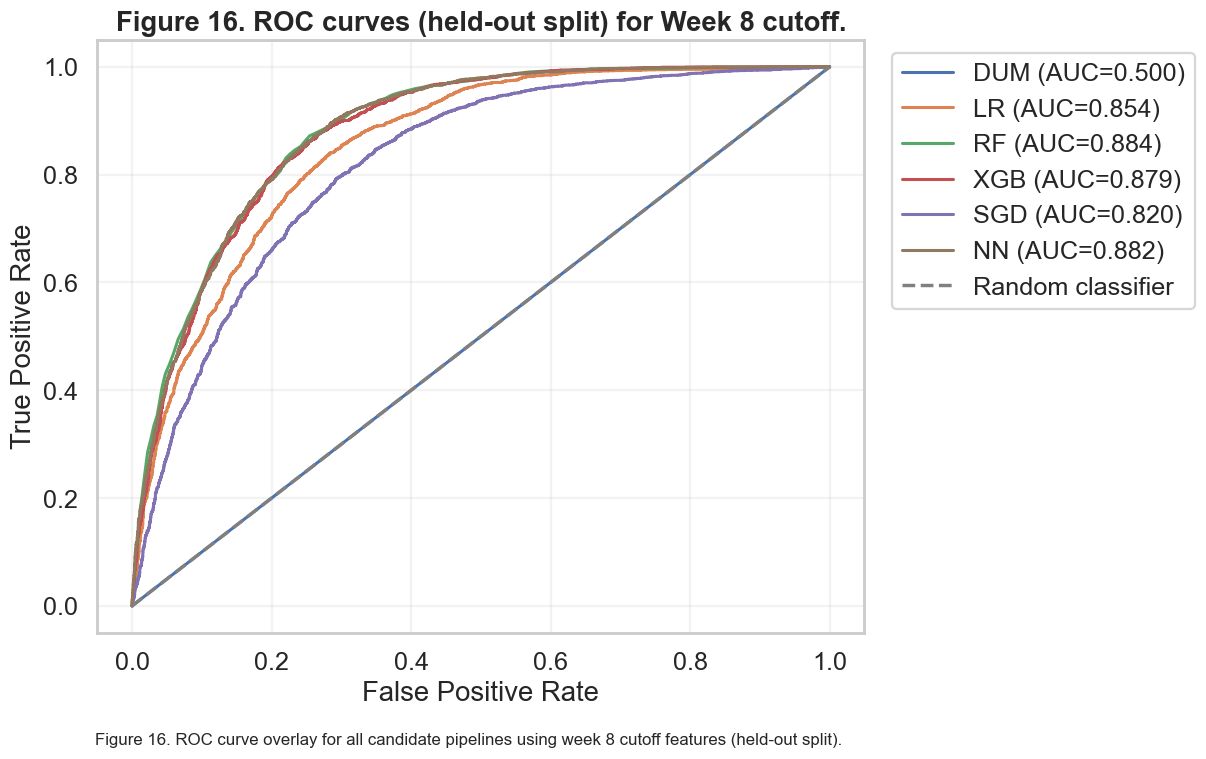

In [ ]:
# -------------------------------------------------------------------
# 7.4 ROC curve overlays (held-out split evaluation)
# -------------------------------------------------------------------

# Prefer Stage 6-trained models if they exist; otherwise re-train quickly for ROC plots.
feature_tables = require('feature_tables')
WEEK_CUTOFFS = require('WEEK_CUTOFFS')
RANDOM_SEED = require('RANDOM_SEED')
load_and_clean = require('load_and_clean')
get_prediction_scores = require('get_prediction_scores')
build_stage6_candidate_models = require('build_stage6_candidate_models')

# Reuse Stage 6's held-out split so ROC curves match the reported test metrics.
from sklearn.metrics import roc_curve, roc_auc_score

# If Stage 6 already trained these, reuse. Otherwise, create.
trained_stage6_models = globals().get('trained_stage6_models')

weeks = list(WEEK_CUTOFFS)
for i, week in enumerate(weeks):
    fig_num = 13 + i

    df_week = feature_tables[week]
    X, y, groups, nominal_cols, ordinal_cols, num_cols = load_and_clean(df_week, week)

    stage6_splits = globals().get('stage6_splits')
    if stage6_splits is None or week not in stage6_splits:
        raise RuntimeError('Missing `stage6_splits` for this week. Run Stage 6 before Stage 7.')

    split = stage6_splits[week]
    X_train_val = X.iloc[split['train_val_idx']]
    y_train_val = y.iloc[split['train_val_idx']]
    X_test = X.iloc[split['test_idx']]
    y_test = y.iloc[split['test_idx']]

    if trained_stage6_models is None or week not in trained_stage6_models:
        models = build_stage6_candidate_models(nominal_cols, ordinal_cols, num_cols)
        fitted = {}
        for tag, model in models.items():
            model.fit(X_train_val, y_train_val)
            fitted[tag] = model
    else:
        fitted = trained_stage6_models[week]

    fig, ax = plt.subplots(figsize=(9, 7))
    for model_tag, model in fitted.items():
        y_scores = get_prediction_scores(model, X_test)
        fpr, tpr, _ = roc_curve(y_test, y_scores)
        auc_score = roc_auc_score(y_test, y_scores)
        ax.plot(fpr, tpr, linewidth=2.0, label=f"{model_tag} (AUC={auc_score:.3f})")

    ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f"Figure {fig_num}. ROC curves (held-out split) for Week {week} cutoff.")
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(alpha=0.25)

    out_path = PERF_DIR / f"fig{fig_num:02d}_roc_overlay_week{week}.png"
    save_report_fig(
        fig,
        out_path,
        caption=(
            f"Figure {fig_num}. ROC curve overlay for all candidate pipelines using week {week} cutoff features (held-out split)."
        ),
    )
    plt.show()


In [ ]:
# -------------------------------------------------------------------
# 7.5 Write a small figure manifest for the report
# -------------------------------------------------------------------

from pathlib import Path


def _list_files(base: Path, patterns: list[str]) -> list[Path]:
    files: list[Path] = []
    for pat in patterns:
        files.extend(base.glob(pat))
    # de-dup and sort by name
    uniq = {p.resolve(): p for p in files}
    return [uniq[k] for k in sorted(uniq.keys(), key=lambda p: str(p))]


manifest_lines: list[str] = []
manifest_lines.append("# Report Figure Manifest")
manifest_lines.append("")
manifest_lines.append("Generated by Stage 7 in `project.ipynb`. Paths are relative to repo root.")

# Diagram
manifest_lines.append("")
manifest_lines.append("## Diagram")
for p in _list_files(DIAGRAM_DIR, ["fig*.png", "fig*.pdf"]):
    manifest_lines.append(f"- {p.as_posix()}")

# EDA
manifest_lines.append("")
manifest_lines.append("## EDA (Stage 2 outputs)")
for p in _list_files(EDA_DIR, ["fig*.png", "fig*.pdf"]):
    manifest_lines.append(f"- {p.as_posix()}")

# Performance
manifest_lines.append("")
manifest_lines.append("## Performance")
for p in _list_files(PERF_DIR, ["fig*.png", "fig*.pdf"]):
    manifest_lines.append(f"- {p.as_posix()}")

out_path = FIG_ROOT / "REPORT_FIGURES.md"
out_path.write_text("\n".join(manifest_lines) + "\n", encoding="utf-8")
print(f"Wrote {out_path}")


### Report Figure Manifest (for PDF)

Below is the current manifest (also saved to `figures/REPORT_FIGURES.md`):

# Report Figure Manifest

Generated by Stage 7 in `project.ipynb`. Paths are relative to repo root.

## Diagram
- figures/diagram/fig00_methodology_block_diagram.pdf
- figures/diagram/fig00_methodology_block_diagram.png

## EDA (Stage 2 outputs)
- figures/eda/fig01_class_balance.png
- figures/eda/fig02_demographic_outcomes.png
- figures/eda/fig03_region_pass_rate.png
- figures/eda/fig04_correlation_matrix.png
- figures/eda/fig05_vle_clicks_by_outcome.png
- figures/eda/fig06_cumulative_clicks_trajectory.png
- figures/eda/fig07_top_correlated_features.png
- figures/eda/fig08_imd_and_prev_attempts.png

## Performance
- figures/performance/fig09_holdout_auc_by_week.png
- figures/performance/fig10_holdout_f1_by_week.png
- figures/performance/fig11_holdout_auc_trends.png
- figures/performance/fig12_holdout_auc_heatmap.png
- figures/performance/fig13_roc_overlay_week2.png
- figures/performance/fig14_roc_overlay_week4.png
- figures/performance/fig15_roc_overlay_week6.png
- figures/performance/fig16_roc_overlay_week8.png
